# Verificacion de Secciones Eficaces Multigrupo

Notebook unificado que verifica el colapso multigrupo de secciones eficaces
para los tres tipos de funcion de ponderacion soportados por NJOY/GAMINR
(`ITW=1`, `ITW=2`, `ITW=3`) y frente a XrayDB con el mismo peso de colapso.

Estructura siguiendo la subseccion *Verificacion de secciones eficaces multigrupo*:

| Bloque | Contenido |
|:------:|:----------|
| 0 | Imports y configuracion global |
| 1 | Constantes, grupos de energia, materiales |
| 2 | `PointCrossSections` (PE Biggs-Lighthill + Compton KN x S(x,Z)) |
| 3 | `MultiGroupCrossSections` parametrizado en IWT |
| 4 | Funciones auxiliares: parser GENDF y colapso XrayDB |
| 5 | Colapso multigrupo frente a XrayDB |
| 6 | Colapso multigrupo frente a NJOY/GAMINR con ITW=1 (peso SpekPy) |
| 7 | Colapso multigrupo frente a NJOY/GAMINR con ITW=2 (peso plano) |
| 8 | Colapso multigrupo frente a NJOY/GAMINR con ITW=3 (peso 1/E o E^2) |
| 9 | Resumen tecnico final |

**Referencias:** Acuros CTS (Maslowski 2018), Vassiliev (cap. 7),
NJOY16 GAMINR (sec. 9), ENDF/B-VII.1 MT=504.


## 1. Imports y backend

In [1]:
# Imports
import math
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Backend GPU/CPU (opcional, no se usa intensivamente aqui)
try:
    import cupy as cp
    _CUPY_OK, xp = True, cp
    print('OK   CuPy disponible')
except Exception as e:
    _CUPY_OK, xp = False, np
    print(f'INFO CuPy no disponible ({e}) -- usando NumPy')

# XrayDB para referencia puntual y como referencia de colapso (Bloque 5)
try:
    import xraydb
    _XRAYDB_OK = True
    print('OK   xraydb disponible')
except Exception as e:
    _XRAYDB_OK = False
    print(f'WARNING xraydb no disponible ({e}) -- pip install xraydb')

# Configuracion de pandas para tablas legibles
pd.set_option('display.float_format', lambda x: f'{x:.4g}')
pd.set_option('display.width', 220)


OK   CuPy disponible
OK   xraydb disponible


## 2. Constantes fisicas, grupos de energia y materiales

Definimos los grupos multigrupo 10x10 keV (rango activo 20-80 keV), las
constantes CGS, las composiciones de referencia (H2O, aire) y los pesos
atomicos.


In [2]:
# Constantes fisicas (CGS)
N_A          = 6.02214076e23      # mol^-1
r_e_cm       = 2.8179403262e-13   # cm
sigma_T_cm2  = (8.0*math.pi/3.0) * r_e_cm**2
mec2_keV     = 511.0              # keV
DELTA_E_KEV  = 1.0                # keV (paso de discretizacion fino)

# Grupos de energia (E_sup, E_inf] en keV  (orden BTE: alta -> baja)
ENERGY_GROUPS = [
    (100, 90), (90, 80), (80, 70), (70, 60), (60, 50),
    (50, 40),  (40, 30), (30, 20), (20, 10), (10,  0),
]
N_GROUPS  = len(ENERGY_GROUPS)
E_MIN_KEV = 20.0
E_MAX_KEV = 80.0

def active_groups():
    return [g for g, (hi, lo) in enumerate(ENERGY_GROUPS)
            if hi > E_MIN_KEV and lo < E_MAX_KEV]

def energy_bins_in_group(g):
    hi, lo = ENERGY_GROUPS[g]
    return np.arange(float(lo) + 0.5, float(hi) + 0.5, DELTA_E_KEV)

def energy_bins_in_range(g):
    return [E for E in energy_bins_in_group(g) if E_MIN_KEV <= E <= E_MAX_KEV]

def group_of(E_keV):
    for g, (hi, lo) in enumerate(ENERGY_GROUPS):
        if lo < E_keV <= hi:
            return g
    return -1

# Mapeos de grupos activos
GROUP_LABELS   = ['20-30','30-40','40-50','50-60','60-70','70-80']
GROUP_BTE_IDX  = [7, 6, 5, 4, 3, 2]   # indice BTE (desc)
GROUP_NJOY_IDX = [2, 3, 4, 5, 6, 7]   # indice NJOY (asc, 0-based)
N_G            = len(GROUP_LABELS)

# Constantes de elementos
Z_ATOMIC = {'H': 1, 'O': 8, 'N': 7}
A_ATOMIC = {'H': 1.00794, 'N': 14.0067, 'O': 15.9994}

# Materiales (fraccion masica en %)
_MEDIA = pd.DataFrame({
    'Media_number': [0,     1],
    'Media_name':   ['Air', 'Water'],
    'Density':      [0.0012, 1.0],
    'H':  [ 0.0,   11.1898],
    'O':  [22.0,   88.8102],   # nota: aqui es molar para aire (se trata abajo)
    'N':  [78.0,    0.0   ],
}).set_index('Media_number')

COMP_H2O = _MEDIA.loc[1:1]
COMP_AIR = _MEDIA.loc[0:0]
RHO_H2O  = 1.0
RHO_AIR  = 0.0012

def comp_pure(elem):
    return pd.DataFrame({'H':[0.0],'O':[0.0],'N':[0.0], elem:[100.0]})

# Fracciones MASICAS reales para las comparaciones con XrayDB/NJOY
H2O_WFRAC = {'H': 0.111898, 'O': 0.888102}
AIRE_WFRAC = {'N': 0.78,    'O': 0.22}   # aproximacion molar->masica del solver

print('OK  Grupos activos:', active_groups(), f'(rango {E_MIN_KEV}-{E_MAX_KEV} keV)')
print('    Etiquetas:', GROUP_LABELS)


OK  Grupos activos: [2, 3, 4, 5, 6, 7] (rango 20.0-80.0 keV)
    Etiquetas: ['20-30', '30-40', '40-50', '50-60', '60-70', '70-80']


## 3. `PointCrossSections`

Secciones eficaces puntuales autocontenidas:

* **Fotoelectrico Biggs-Lighthill** (H, N, O).
* **Compton incoherente** $\mathrm{KN}\times S(x,Z)$ con tablas
  ENDF/B-VII.1 MT=504 (interpolacion log-log).

Refs: Acuros Eq.(1); Vassiliev Sec.3.1; NJOY GAMINR Sec.9.1, Eq.(380).


In [3]:
# ── Tablas S(x,Z) ENDF/B-VII.1 MT=504 ───────────────────────────────────
_S_X_H = np.array([
    0.000000e+00, 1.000000e-07, 1.000000e-06, 1.000000e-05, 1.000000e-04, 1.000000e-03,
    5.000000e-03, 1.000000e-02, 1.500000e-02, 2.000000e-02, 2.500000e-02, 3.000000e-02,
    3.750000e-02, 4.000000e-02, 4.750000e-02, 5.000000e-02, 5.875000e-02, 6.625000e-02,
    7.000000e-02, 7.875000e-02, 8.000000e-02, 8.625000e-02, 9.000000e-02, 9.750000e-02,
    1.000000e-01, 1.062500e-01, 1.156300e-01, 1.250000e-01, 1.359400e-01, 1.453100e-01,
    1.500000e-01, 1.609400e-01, 1.703100e-01, 1.750000e-01, 1.875000e-01, 2.000000e-01,
    2.125000e-01, 2.218800e-01, 2.289100e-01, 2.359400e-01, 2.429700e-01, 2.500000e-01,
    2.625000e-01, 2.718800e-01, 2.789100e-01, 2.906300e-01, 2.929700e-01, 3.000000e-01,
    3.179700e-01, 3.250000e-01, 3.330100e-01, 3.497600e-01, 3.625000e-01, 3.677000e-01,
    3.892300e-01, 4.000000e-01, 4.250000e-01, 4.437500e-01, 4.500000e-01, 4.718800e-01,
    5.000000e-01, 5.250000e-01, 5.625000e-01, 6.000000e-01, 6.500000e-01, 7.000000e-01,
    7.500000e-01, 8.000000e-01, 8.750000e-01, 9.000000e-01, 1.000000e+00, 1.125000e+00,
    1.250000e+00, 1.437500e+00, 1.500000e+00, 1.750000e+00, 2.000000e+00, 2.500000e+00,
    3.000000e+00, 3.500000e+00, 4.000000e+00, 5.000000e+00, 6.000000e+00, 7.000000e+00,
    8.000000e+00, 1.000000e+01, 1.500000e+01, 2.000000e+01, 5.000000e+01, 8.000000e+01,
    1.000000e+02, 1.000000e+03, 1.000000e+06, 1.000000e+09,
], dtype=float)
_S_VAL_H = np.array([
    0.000000e+00, 4.409700e-13, 4.409700e-11, 4.409700e-09, 4.409700e-07, 4.409700e-05,
    1.102425e-03, 4.409700e-03, 9.887600e-03, 1.749400e-02, 2.716600e-02, 3.882600e-02,
    5.983670e-02, 6.772900e-02, 9.383850e-02, 1.033100e-01, 1.391020e-01, 1.726290e-01,
    1.902300e-01, 2.329580e-01, 2.392320e-01, 2.710060e-01, 2.903800e-01, 3.294640e-01,
    3.425600e-01, 3.752390e-01, 4.238310e-01, 4.713000e-01, 5.245410e-01, 5.678810e-01,
    5.887300e-01, 6.347230e-01, 6.712280e-01, 6.885000e-01, 7.310720e-01, 7.688400e-01,
    8.019520e-01, 8.240260e-01, 8.392010e-01, 8.530840e-01, 8.658780e-01, 8.776800e-01,
    8.961610e-01, 9.082310e-01, 9.163850e-01, 9.283980e-01, 9.305910e-01, 9.368600e-01,
    9.502770e-01, 9.546510e-01, 9.592280e-01, 9.673380e-01, 9.723280e-01, 9.741820e-01,
    9.804080e-01, 9.829800e-01, 9.875650e-01, 9.901100e-01, 9.908580e-01, 9.930070e-01,
    9.950200e-01, 9.962740e-01, 9.975580e-01, 9.983700e-01, 9.989660e-01, 9.994100e-01,
    9.995910e-01, 9.997600e-01, 9.998670e-01, 9.999000e-01, 9.999500e-01, 9.999710e-01,
    9.999900e-01, 9.999980e-01, 1.000000e+00, 1.000000e+00, 1.000000e+00, 1.000000e+00,
    1.000000e+00, 1.000000e+00, 1.000000e+00, 1.000000e+00, 1.000000e+00, 1.000000e+00,
    1.000000e+00, 1.000000e+00, 1.000000e+00, 1.000000e+00, 1.000000e+00, 1.000000e+00,
    1.000000e+00, 1.000000e+00, 1.000000e+00, 1.000000e+00,
], dtype=float)

_S_X_O = np.array([
    0.000000e+00, 1.000000e-07, 1.000000e-06, 1.000000e-05, 1.000000e-04, 1.000000e-03,
    5.000000e-03, 6.250000e-03, 7.187500e-03, 7.890600e-03, 8.945300e-03, 1.000000e-02,
    1.500000e-02, 1.750000e-02, 2.000000e-02, 2.500000e-02, 3.000000e-02, 4.000000e-02,
    5.000000e-02, 6.000000e-02, 7.000000e-02, 8.000000e-02, 8.500000e-02, 9.000000e-02,
    1.000000e-01, 1.125000e-01, 1.250000e-01, 1.375000e-01, 1.500000e-01, 1.625000e-01,
    1.750000e-01, 1.875000e-01, 1.937500e-01, 2.000000e-01, 2.125000e-01, 2.312500e-01,
    2.500000e-01, 2.718800e-01, 2.906300e-01, 3.000000e-01, 3.250000e-01, 3.437500e-01,
    3.625000e-01, 3.718800e-01, 4.000000e-01, 4.250000e-01, 4.625000e-01, 4.750000e-01,
    5.000000e-01, 5.500000e-01, 5.875000e-01, 6.000000e-01, 6.500000e-01, 7.000000e-01,
    7.500000e-01, 8.000000e-01, 9.000000e-01, 1.000000e+00, 1.109400e+00, 1.203100e+00,
    1.250000e+00, 1.312500e+00, 1.406300e+00, 1.500000e+00, 1.589800e+00, 1.665000e+00,
    1.748800e+00, 1.750000e+00, 1.838500e+00, 1.919300e+00, 2.000000e+00, 2.062500e+00,
    2.335900e+00, 2.375000e+00, 2.445300e+00, 2.500000e+00, 2.750000e+00, 2.835900e+00,
    2.894500e+00, 2.947300e+00, 3.000000e+00, 3.062500e+00, 3.117200e+00, 3.212900e+00,
    3.392300e+00, 3.464100e+00, 3.500000e+00, 3.562500e+00, 3.671900e+00, 3.877000e+00,
    3.959000e+00, 4.000000e+00, 4.091800e+00, 4.176000e+00, 4.279000e+00, 4.327100e+00,
    5.000000e+00, 5.125000e+00, 5.343800e+00, 5.753900e+00, 5.918000e+00, 6.000000e+00,
    6.562500e+00, 7.000000e+00, 8.000000e+00, 1.000000e+01, 1.500000e+01, 1.000000e+09,
], dtype=float)
_S_VAL_O = np.array([
    0.000000e+00, 1.100000e-12, 1.100000e-10, 1.100000e-08, 1.100000e-06, 1.100000e-04,
    2.750000e-03, 4.296875e-03, 5.682617e-03, 6.848773e-03, 8.802023e-03, 1.100000e-02,
    2.530000e-02, 3.441520e-02, 4.480000e-02, 6.980000e-02, 1.001000e-01, 1.761000e-01,
    2.710000e-01, 3.841910e-01, 5.137000e-01, 6.568110e-01, 7.328590e-01, 8.118000e-01,
    9.770000e-01, 1.194080e+00, 1.419900e+00, 1.651210e+00, 1.885000e+00, 2.118480e+00,
    2.349700e+00, 2.576840e+00, 2.688710e+00, 2.799000e+00, 3.014080e+00, 3.322920e+00,
    3.613500e+00, 3.927910e+00, 4.176130e+00, 4.293000e+00, 4.580310e+00, 4.774320e+00,
    4.951080e+00, 5.033340e+00, 5.257000e+00, 5.429000e+00, 5.647990e+00, 5.711810e+00,
    5.828000e+00, 6.020960e+00, 6.139280e+00, 6.175000e+00, 6.301780e+00, 6.411000e+00,
    6.507880e+00, 6.596000e+00, 6.755000e+00, 6.901000e+00, 7.047320e+00, 7.161580e+00,
    7.215900e+00, 7.283300e+00, 7.377340e+00, 7.462000e+00, 7.533340e+00, 7.586660e+00,
    7.639770e+00, 7.640450e+00, 7.689840e+00, 7.729440e+00, 7.764200e+00, 7.787300e+00,
    7.867040e+00, 7.875420e+00, 7.890010e+00, 7.899900e+00, 7.934000e+00, 7.943210e+00,
    7.948220e+00, 7.952650e+00, 7.957000e+00, 7.960700e+00, 7.963880e+00, 7.969320e+00,
    7.976770e+00, 7.979400e+00, 7.980700e+00, 7.982170e+00, 7.984680e+00, 7.989170e+00,
    7.990400e+00, 7.991000e+00, 7.991770e+00, 7.992470e+00, 7.993300e+00, 7.993680e+00,
    7.997700e+00, 7.997920e+00, 7.998280e+00, 7.998930e+00, 7.999180e+00, 7.999300e+00,
    7.999590e+00, 7.999800e+00, 8.000000e+00, 8.000000e+00, 8.000000e+00, 8.000000e+00,
], dtype=float)

_S_X_N = np.array([
    0.000000e+00, 1.000000e-07, 1.000000e-06, 1.000000e-05, 1.000000e-04, 1.000000e-03,
    5.000000e-03, 6.718700e-03, 7.890600e-03, 9.296900e-03, 1.000000e-02, 1.125000e-02,
    1.500000e-02, 2.000000e-02, 2.500000e-02, 3.000000e-02, 4.000000e-02, 5.000000e-02,
    5.875000e-02, 6.000000e-02, 7.000000e-02, 8.000000e-02, 9.000000e-02, 1.000000e-01,
    1.109400e-01, 1.125000e-01, 1.203100e-01, 1.250000e-01, 1.375000e-01, 1.500000e-01,
    1.625000e-01, 1.750000e-01, 1.875000e-01, 1.937500e-01, 2.000000e-01, 2.125000e-01,
    2.312500e-01, 2.500000e-01, 2.718800e-01, 2.750000e-01, 2.906300e-01, 3.000000e-01,
    3.250000e-01, 3.437500e-01, 3.718800e-01, 4.000000e-01, 4.437500e-01, 4.812500e-01,
    5.000000e-01, 5.250000e-01, 5.625000e-01, 5.750000e-01, 6.000000e-01, 6.500000e-01,
    7.000000e-01, 8.000000e-01, 8.750000e-01, 9.000000e-01, 9.750000e-01, 1.000000e+00,
    1.085900e+00, 1.144500e+00, 1.214800e+00, 1.250000e+00, 1.312500e+00, 1.406300e+00,
    1.500000e+00, 1.617200e+00, 1.712900e+00, 1.750000e+00, 1.784700e+00, 1.838500e+00,
    1.919300e+00, 2.000000e+00, 2.062500e+00, 2.308600e+00, 2.375000e+00, 2.377000e+00,
    2.459000e+00, 2.500000e+00, 2.750000e+00, 2.835900e+00, 2.894500e+00, 2.947300e+00,
    3.000000e+00, 3.062500e+00, 3.117200e+00, 3.212900e+00, 3.392300e+00, 3.464100e+00,
    3.500000e+00, 3.562500e+00, 3.671900e+00, 4.000000e+00, 4.125000e+00, 4.234400e+00,
    4.425800e+00, 5.000000e+00, 5.250000e+00, 5.718800e+00, 6.000000e+00, 6.625000e+00,
    6.875000e+00, 7.000000e+00, 7.250000e+00, 7.718800e+00, 7.906300e+00, 8.000000e+00,
    8.125000e+00, 8.359400e+00, 8.654200e+00, 8.900900e+00, 9.529000e+00, 1.000000e+01,
    1.045900e+01, 1.088000e+01, 1.139500e+01, 1.205600e+01, 1.247700e+01, 1.373800e+01,
    1.500000e+01, 1.718800e+01, 1.906300e+01, 2.000000e+01, 2.187500e+01, 2.363300e+01,
    2.692900e+01, 2.981300e+01, 5.000000e+01, 5.750000e+01, 8.000000e+01, 1.000000e+02,
    1.270300e+02, 1.557000e+02, 1.855600e+02, 2.162100e+02, 2.652000e+02, 3.326500e+02,
    3.945400e+02, 4.702300e+02, 5.673500e+02, 6.755100e+02, 8.174800e+02, 1.000000e+03,
    1.171400e+03, 1.365400e+03, 1.706700e+03, 2.048600e+03, 2.521700e+03, 3.357900e+03,
    4.681900e+03, 6.333900e+03, 1.036300e+04, 1.589300e+04, 3.032700e+04, 7.267300e+04,
    2.695800e+05, 1.000000e+06, 5.623400e+06, 5.424700e+07, 1.000000e+09,
], dtype=float)
_S_VAL_N = np.array([
    0.000000e+00, 1.300000e-12, 1.300000e-10, 1.300000e-08, 1.300000e-06, 1.300000e-04,
    3.250000e-03, 5.868321e-03, 8.094004e-03, 1.123621e-02, 1.300000e-02, 1.649010e-02,
    2.920000e-02, 5.170000e-02, 8.040000e-02, 1.151000e-01, 2.017000e-01, 3.100000e-01,
    4.200330e-01, 4.368180e-01, 5.797000e-01, 7.364600e-01, 9.042000e-01, 1.080000e+00,
    1.278750e+00, 1.307440e+00, 1.452170e+00, 1.539700e+00, 1.772470e+00, 2.003000e+00,
    2.228330e+00, 2.446800e+00, 2.657050e+00, 2.758520e+00, 2.858000e+00, 3.048640e+00,
    3.315380e+00, 3.558600e+00, 3.812940e+00, 3.846890e+00, 4.007360e+00, 4.097000e+00,
    4.311800e+00, 4.453020e+00, 4.636790e+00, 4.792000e+00, 4.987420e+00, 5.122470e+00,
    5.182000e+00, 5.254070e+00, 5.350560e+00, 5.380580e+00, 5.437000e+00, 5.540240e+00,
    5.635000e+00, 5.809000e+00, 5.929580e+00, 5.968000e+00, 6.077840e+00, 6.113000e+00,
    6.226560e+00, 6.298480e+00, 6.378060e+00, 6.415700e+00, 6.477240e+00, 6.558950e+00,
    6.630000e+00, 6.703240e+00, 6.753430e+00, 6.770310e+00, 6.785630e+00, 6.806880e+00,
    6.835130e+00, 6.859900e+00, 6.875510e+00, 6.923390e+00, 6.932290e+00, 6.932540e+00,
    6.942620e+00, 6.947000e+00, 6.966450e+00, 6.971560e+00, 6.974260e+00, 6.976650e+00,
    6.979000e+00, 6.980790e+00, 6.982330e+00, 6.984950e+00, 6.989520e+00, 6.990710e+00,
    6.991300e+00, 6.991920e+00, 6.992990e+00, 6.996000e+00, 6.996430e+00, 6.996790e+00,
    6.997410e+00, 6.999100e+00, 6.999290e+00, 6.999620e+00, 6.999800e+00, 6.999860e+00,
    6.999890e+00, 6.999900e+00, 6.999930e+00, 6.999970e+00, 6.999990e+00, 7.000000e+00,
    7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00,
    7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00,
    7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00,
    7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00,
    7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00,
    7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00,
    7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00,
    7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00,
    7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00,
], dtype=float)

_SF_TABLES = {'H': (_S_X_H, _S_VAL_H), 'O': (_S_X_O, _S_VAL_O), 'N': (_S_X_N, _S_VAL_N)}



def _compute_x_incoherent(E_keV, cos_theta):
    '''Variable x = q*20.60744 (NJOY GAMINR Eq.(383)).'''
    k = E_keV / mec2_keV
    dmu = 1.0 - cos_theta
    denom = 1.0 + k * dmu
    if denom <= 0.0:
        return 0.0
    num_sq = 1.0 + (k**2 + 2.0*k) * dmu / 2.0
    q = 2.0*k * math.sqrt(max(0.0, dmu/2.0)) * math.sqrt(max(0.0, num_sq)) / denom
    return 20.60744 * q


def _interp_scatter_function(x, elem):
    '''Interpolacion log-log de S(x,Z) en tablas ENDF/B-VII.1 MT=504.'''
    x_tbl, s_tbl = _SF_TABLES.get(elem, (None, None))
    if x_tbl is None or x <= 0.0:
        return 0.0
    if x >= x_tbl[-1]:
        return float(s_tbl[-1])
    eps = 1e-12
    mask = x_tbl > 0
    return float(math.exp(np.interp(
        math.log(x),
        np.log(x_tbl[mask]),
        np.log(np.clip(s_tbl[mask], eps, None)))))


class PointCrossSections:
    '''XS puntuales: PE Biggs-Lighthill + Compton KN x S(x,Z).
    Ref: Acuros Eq.(1); Vassiliev Sec.3.1; NJOY GAMINR Sec.9.1.
    '''

    def __init__(self):
        self._pe = {
            'H': {
                'S': [0.8,  4.0,  20.0, 100.0, 500.0],
                'E': [4.0,  20.0, 100.0, 500.0, 1e99 ],
                'A1':[ 7.636e-02, 1.180e-03, 3.7783e-05, 1.034e-06, 4.599e-07],
                'A2':[-9.406e-01,-8.236e-02,-9.2692e-03,-4.114e-04, 5.006e-04],
                'A3':[ 6.144e+00, 2.886e+00, 1.3761e+00, 6.287e-01,-1.425e-02],
                'A4':[ 1.425e+00, 5.534e+00, 1.5914e+01, 3.927e+01, 1.960e+02],
            },
            'N': {
                'S': [0.8,  4.0,  20.0, 100.0, 500.0],
                'E': [4.0,  20.0, 100.0, 500.0, 1e99 ],
                'A1':[-4.940e+00, 2.019e+00, 6.9367e-02, 1.872e-03, 8.122e-04],
                'A2':[-8.442e+01,-1.249e+02,-1.7360e+01,-6.732e-01, 8.364e-01],
                'A3':[ 4.620e+03, 4.609e+03, 2.8059e+03, 1.282e+03, 4.410e+02],
                'A4':[-1.186e+03,-9.421e+02, 1.1254e+04, 5.700e+04, 2.358e+05],
            },
            'O': {
                'S': [0.532, 4.0,  20.0, 100.0, 500.0],
                'E': [4.0,  20.0, 100.0, 500.0, 1e99 ],
                'A1':[-7.181e+01, 2.745e+00, 1.1264e-01, 3.169e-03, 1.367e-03],
                'A2':[ 4.748e+02,-1.747e+02,-2.8287e+01,-1.146e+00, 1.473e+00],
                'A3':[ 5.542e+03, 7.159e+03, 4.6739e+03, 2.194e+03, 7.214e+02],
                'A4':[-1.363e+03,-2.213e+03, 1.5005e+04, 9.131e+04, 4.048e+05],
            },
        }
        self._elements = ['H', 'O', 'N']
        self._ZA   = {'H': 0.9921, 'O': 0.5, 'N': 4.998e-01}
        self._Zmap = dict(Z_ATOMIC)
        self._mu_q, self._w_q = np.polynomial.legendre.leggauss(64)

    def _kn(self, E, mu):
        a = E / mec2_keV
        if a <= 0:
            return 0.0
        k = 1.0 / (1.0 + a*(1.0 - mu))
        if k <= 0:
            return 0.0
        return max(0.0, 0.5*r_e_cm**2 * k**2 * (k + 1.0/k - (1.0 - mu**2)))

    def photoelectric_mu_over_rho(self, E, comp):
        '''mu_PE/rho [cm2/g] por Biggs-Lighthill. Acuros Eq.(1).'''
        mu = 0.0
        for el in self._elements:
            w = float(comp[el].values[0]) / 100.0
            if w <= 0:
                continue
            p = self._pe.get(el)
            if p is None:
                continue
            for i in range(len(p['S'])):
                if p['S'][i] <= E < p['E'][i]:
                    mu += w*(p['A1'][i]/E + p['A2'][i]/E**2
                             + p['A3'][i]/E**3 + p['A4'][i]/E**4)
                    break
        return max(0.0, mu)

    def compton_mu_over_rho(self, E, comp):
        '''mu_C/rho [cm2/g] = N_A * 2pi * int(S * dsigma_KN dmu).
        Ref: NJOY GAMINR Eq.(380).'''
        if E <= 0:
            return 0.0
        s = 0.0
        for mu_q, w_q in zip(self._mu_q, self._w_q):
            dsig = self._kn(E, float(mu_q))
            if dsig <= 0.0:
                continue
            xv = _compute_x_incoherent(E, float(mu_q))
            Sm = sum(
                float(comp[el].values[0])/100.0
                * self._ZA[el]
                * _interp_scatter_function(xv, el)
                / float(self._Zmap[el])
                for el in self._elements
                if float(comp[el].values[0]) > 0
            )
            s += float(w_q) * dsig * Sm
        return max(0.0, s * 2.0*math.pi * N_A)

    def total_mu(self, E, rho, comp):
        return max(0.0, (self.photoelectric_mu_over_rho(E, comp)
                         + self.compton_mu_over_rho(E, comp)) * rho)

    def macroscopic_photoelectric(self, E, rho, comp):
        return rho * self.photoelectric_mu_over_rho(E, comp)

    def macroscopic_compton(self, E, rho, comp):
        return rho * self.compton_mu_over_rho(E, comp)

    def macroscopic_total(self, E, rho, comp):
        return self.total_mu(E, rho, comp)

    def electron_density(self, rho, comp):
        return rho * N_A * sum(
            float(comp[el].values[0])/100.0 * self._ZA[el]
            for el in self._elements
            if float(comp[el].values[0]) > 0
        )


xs = PointCrossSections()
print('OK  PointCrossSections instanciada como `xs`')


OK  PointCrossSections instanciada como `xs`


## 4. `MultiGroupCrossSections` parametrizado en IWT

El colapso multigrupo se define como

$$
\sigma_g \;=\; \frac{\sum_{n\in g} w(E_n)\,\sigma(E_n)}{\sum_{n\in g} w(E_n)}
$$

(NJOY/GAMINR Eq. (384); Vassiliev Sec. 7.2.1). El peso $w(E)$ depende del modo
seleccionado en NJOY/GAMINR `ITW`:

| `ITW` | Significado en NJOY/GAMINR | $w(E)$ usado en este notebook |
|:-----:|:---------------------------|:------------------------------|
| 1 | Peso tabulado por el usuario | espectro SpekPy leido de archivo |
| 2 | Peso constante (plano) | $w(E)=1$ |
| 3 | Peso $1/E$ con suavizados en los extremos | $w(E)=1/E$ (peso ideal) o $w(E)=E^2$ (peso efectivo del tape) |

> **Nota practica.** En el caso `ITW=3` se proporciona la opcion `EFFECTIVE`
> ($w(E)=E^2$) detectada experimentalmente en el flux almacenado en MF=23 de
> los tapes generados (ver Bloque 8). Si la malla NJOY usa el peso $1/E$ puro,
> elegir `IDEAL`.

La clase `MultiGroupCrossSections` recibe un *callable* `weight_fn` y aplica
la misma formula para cualquier peso.


In [4]:
# Pesos disponibles ---------------------------------------------------------
def make_weight_flat():
    '''ITW=2: w(E)=1 (peso plano).'''
    def w(E):
        return 1.0
    w.label = 'ITW=2 (plano, w=1)'
    return w


def make_weight_one_over_E():
    '''ITW=3 ideal: w(E)=1/E.'''
    def w(E):
        E = float(E)
        return 1.0 / E if E > 0 else 0.0
    w.label = 'ITW=3 ideal (1/E)'
    return w


def make_weight_E_squared():
    '''ITW=3 efectivo observado en MF=23 del tape generado: w(E)=E^2.'''
    def w(E):
        E = float(E)
        return E*E if E > 0 else 0.0
    w.label = 'ITW=3 efectivo (E^2)'
    return w


def make_weight_tabulated(path, expected_unit_hint=None):
    '''ITW=1: peso tabulado leido de archivo (E[keV o eV], w(E)).

    Detecta unidades por el rango: max > 1000 -> eV (convertido a keV).
    Lectura tolerante a comentarios '#' y '%'. Devuelve callable con .label.
    '''
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(f'No existe el archivo de peso ITW=1: {p}')

    data = np.loadtxt(p, comments=['#', '%'])
    if data.ndim == 1:
        raise ValueError(f'{p}: se esperan >=2 columnas (E, w).')

    E_raw = data[:, 0].astype(float)
    W_raw = data[:, 1].astype(float)

    # Unidades
    if E_raw.max() > 1000.0:
        E_keV = E_raw / 1000.0
        unit_src = 'eV -> keV'
    else:
        E_keV = E_raw.copy()
        unit_src = 'keV'

    # Pesos no negativos
    W = np.clip(W_raw, 0.0, None)

    # Orden creciente en energia (np.interp lo exige)
    isort = np.argsort(E_keV)
    E_keV = E_keV[isort]
    W     = W[isort]

    E_min, E_max = float(E_keV.min()), float(E_keV.max())

    def w(E):
        E = float(E)
        if E < E_min or E > E_max:
            return 0.0
        val = float(np.interp(E, E_keV, W))
        return val if val > 0.0 else 0.0

    w.label   = f'ITW=1 (tabulado, {p.name})'
    w.path    = p
    w.E_keV   = E_keV
    w.W       = W
    w.range   = (E_min, E_max)
    w.unit_src = unit_src
    return w


# MultiGroupCrossSections genericos ------------------------------------------
class MultiGroupCrossSections:
    '''Colapso multigrupo parametrizado en una funcion de peso w(E).'''

    def __init__(self, point_xs, weight_fn):
        self.xs = point_xs
        self.w  = weight_fn
        self.label = getattr(weight_fn, 'label', 'custom')

    def _avg(self, fn, g):
        bins = energy_bins_in_range(g)
        if not bins:
            return 0.0
        num = den = 0.0
        for E in bins:
            wE = self.w(E)
            num += wE * fn(E)
            den += wE
        return num/den if den > 0 else 0.0

    def sigma_total_g(self, g, rho, comp):
        return self._avg(lambda E: self.xs.macroscopic_total(E, rho, comp), g)

    def sigma_pe_g(self, g, rho, comp):
        return self._avg(lambda E: self.xs.macroscopic_photoelectric(E, rho, comp), g)

    def sigma_compton_g(self, g, rho, comp):
        return self._avg(lambda E: self.xs.macroscopic_compton(E, rho, comp), g)

    def sigma_per_atom_g(self, g, elem, mt='compton'):
        '''sigma_g [barns/atomo] para elemento puro.
        mt: 'compton' -> MT=504; 'photo' -> MT=522; 'total' -> MT=501-MT=502.
        '''
        A = A_ATOMIC[elem]
        cp0 = comp_pure(elem)
        if mt == 'compton':
            fn = lambda E: self.xs.compton_mu_over_rho(E, cp0)
        elif mt == 'photo':
            fn = lambda E: self.xs.photoelectric_mu_over_rho(E, cp0)
        else:
            fn = lambda E: (self.xs.photoelectric_mu_over_rho(E, cp0)
                            + self.xs.compton_mu_over_rho(E, cp0))
        return self._avg(fn, g) * A / N_A * 1e24


## 5. Parser GENDF y colapso XrayDB

Funciones auxiliares utilizadas en los Bloques 6, 7 y 8:

* `parse_gendf(path)` lee MF=23 (MT=501, 502, 504, 522) de un tape GENDF.
* `xrdb_avg_g(...)` colapsa $\mu/\rho$ de XrayDB con el peso seleccionado.

Total NJOY: $\sigma_T^\text{NJOY}$ = MT501 $-$ MT502 (total sin Rayleigh).


In [5]:
# -------- Parser GENDF (NJOY/GAMINR MF=23) --------------------------------
MAT_INFO = {100:('H',1,1.00794), 800:('O',8,15.9994), 700:('N',7,14.0067)}


def _gd_float(s):
    s = s.strip()
    if not s:
        return 0.0
    try:
        return float(s)
    except ValueError:
        m = re.match(r'\s*([+-]?\d+\.?\d*)([+-]\d+)\s*$', s)
        if m:
            return float(m.group(1) + 'e' + m.group(2))
        raise


def _gd_split(line):
    if len(line) < 66:
        line = line.ljust(66)
    return ([line[i*11:(i+1)*11] for i in range(6)],
            line[66:70].strip(), line[70:72].strip(), line[72:75].strip())


def parse_gendf(filepath):
    '''Lee MF=23 (MT=501, 502, 504, 522) de un tape GENDF NJOY/GAMINR.

    Devuelve un dict { MAT: {'xs_vector': {MT: array}, 'energy_bounds_eV': array,
                              'ngroups': int} }.
    '''
    lines = Path(filepath).read_text(errors='ignore').splitlines()
    blocks = {}
    for ln in lines:
        if len(ln) < 75:
            continue
        _, mat, mf, mt = _gd_split(ln)
        try:
            mat, mf, mt = int(mat), int(mf), int(mt)
        except ValueError:
            continue
        if mat <= 0 or mf == 0 or mt == 0:
            continue
        blocks.setdefault((mat, mf, mt), []).append(ln)

    data = {}
    for mat in sorted({k[0] for k in blocks}):
        d = {'xs_vector': {}, 'energy_bounds_eV': None, 'ngroups': None}
        if (mat, 1, 451) in blocks:
            fls = []
            for ln in blocks[(mat, 1, 451)][2:]:
                for f in _gd_split(ln)[0]:
                    if f.strip():
                        try:
                            fls.append(_gd_float(f))
                        except Exception:
                            pass
            cands = sorted({v for v in fls if 0.0 <= v <= 1e12})
            if len(cands) >= 2:
                d['energy_bounds_eV'] = np.array(cands, dtype=float)
                d['ngroups'] = len(cands) - 1
        NG = d['ngroups']
        if NG is None:
            continue
        for mtx in (501, 502, 504, 522):
            if (mat, 23, mtx) not in blocks:
                continue
            blk = blocks[(mat, 23, mtx)]
            xa = np.zeros(NG)
            i = 1
            while i < len(blk):
                flds, *_ = _gd_split(blk[i])
                try:
                    nw, ig = int(_gd_float(flds[4])), int(_gd_float(flds[5]))
                except Exception:
                    i += 1; continue
                if nw <= 0 or ig <= 0:
                    i += 1; continue
                vals = []
                nl = (nw + 5) // 6
                for j in range(1, nl + 1):
                    if i + j >= len(blk):
                        break
                    for f in _gd_split(blk[i + j])[0]:
                        if f.strip() and len(vals) < nw:
                            vals.append(_gd_float(f))
                if nw == 2 and 1 <= ig <= NG and len(vals) >= 2:
                    xa[ig-1] = vals[1]
                i += 1 + nl
            d['xs_vector'][mtx] = xa
        data[mat] = d
    return data


# -------- Colapso de XrayDB con el mismo peso ------------------------------
def xrdb_mu_over_rho(E_eV, kind, wfrac):
    '''mu/rho [cm2/g] de XrayDB para una mezcla (fracciones masicas).'''
    if not _XRAYDB_OK:
        return 0.0
    return sum(w * xraydb.mu_elam(el, E_eV, kind=kind) for el, w in wfrac.items())


def xrdb_avg_g(g, kind, wfrac, weight_fn):
    '''Colapso XrayDB: <mu/rho>_g con el peso weight_fn (cm^2/g).'''
    bins = energy_bins_in_range(g)
    if not bins:
        return 0.0
    num = den = 0.0
    for E in bins:
        w = weight_fn(float(E))
        num += w * xrdb_mu_over_rho(E*1000.0, kind, wfrac)
        den += w
    return num/den if den > 0 else 0.0


print('OK  parse_gendf y utilidades XrayDB definidas')


OK  parse_gendf y utilidades XrayDB definidas


## 6. Verificacion previa de XS puntuales (vs XrayDB)

Antes de pasar a multigrupo, validamos rapidamente las XS puntuales
$\mu/\rho(E)$ frente a XrayDB en 20-80 keV. Esto desacopla el error de las XS
puntuales del error introducido por el colapso multigrupo.


  mu/rho [cm2/g]  H2O  -- codigo vs XrayDB  (20-80 keV)
 E   PE_ref   PE_cod  err_PE  C_ref  C_cod     err_C  T_ref  T_cod     err_T
20   0.5439   0.5444 0.08643 0.1774 0.1773  -0.01102 0.7213 0.7217   0.06246
25    0.264   0.2636 -0.1707 0.1812 0.1812  0.002261 0.4452 0.4448   -0.1003
30   0.1458   0.1456 -0.1087 0.1829 0.1829 -0.003449 0.3287 0.3285  -0.05011
35  0.08802  0.08805 0.02732 0.1832 0.1832 -0.008964 0.2713 0.2713   0.00281
40  0.05679  0.05687  0.1325 0.1827 0.1827  -0.01567 0.2395 0.2396   0.01945
45  0.03856  0.03862  0.1661 0.1817 0.1817  -0.01603 0.2203 0.2203   0.01585
50  0.02725  0.02729  0.1554 0.1803 0.1803   -0.0156 0.2076 0.2076  0.006842
55   0.0199  0.01992   0.122 0.1787 0.1787  -0.01949 0.1986 0.1986 -0.005315
60  0.01493  0.01494 0.05883  0.177  0.177  -0.02316  0.192 0.1919  -0.01678
65  0.01146  0.01145 -0.0283 0.1752 0.1752  -0.02326 0.1867 0.1867  -0.02357
70  0.00897 0.008959 -0.1153 0.1734 0.1734  -0.02105 0.1824 0.1823  -0.02568
75 0.007141 0.007128

/tmp/ipykernel_2221/963309609.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


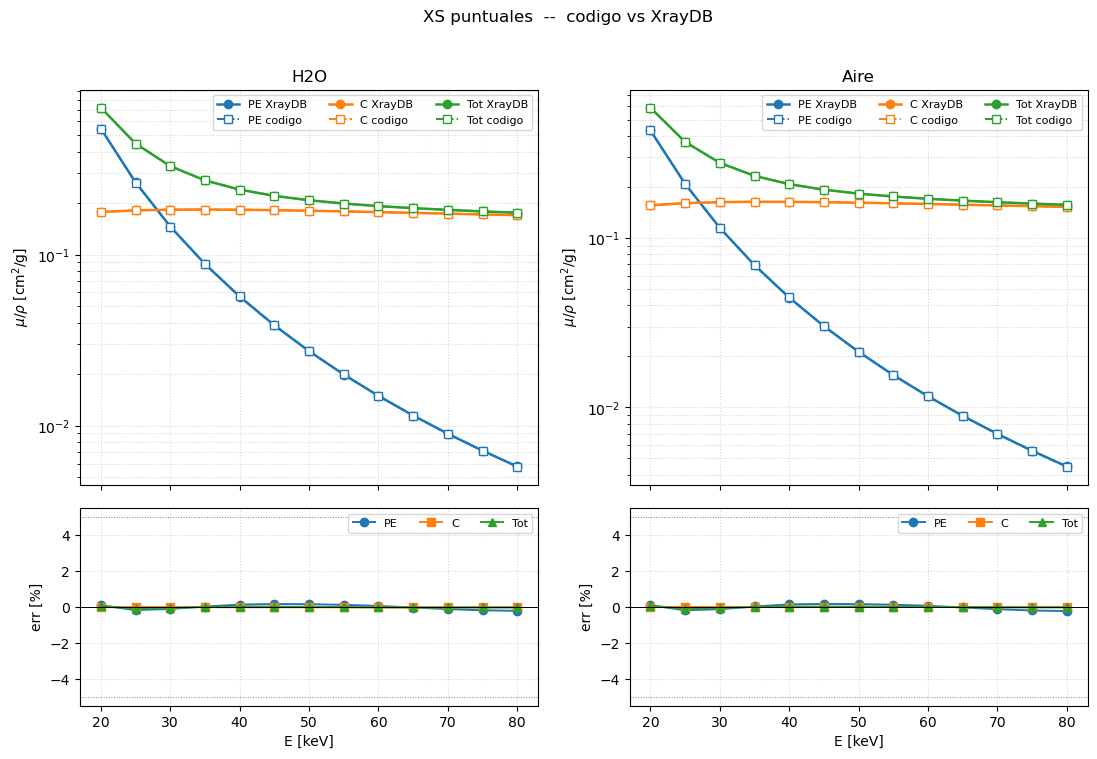

In [6]:
# Verificacion puntual rapida vs XrayDB
E_TEST = [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80]

if not _XRAYDB_OK:
    print('WARNING  xraydb no disponible -- omitiendo Bloque 6 (XS puntuales).')
    res_punt = None
else:
    MATS = [('H2O', COMP_H2O, RHO_H2O, H2O_WFRAC),
            ('Aire', COMP_AIR, RHO_AIR, AIRE_WFRAC)]
    res_punt = {}
    for name, comp, rho, wfrac in MATS:
        rows = []
        for E in E_TEST:
            pe_r = xrdb_mu_over_rho(E*1000.0, 'photo', wfrac)
            co_r = xrdb_mu_over_rho(E*1000.0, 'incoh', wfrac)
            pe_c = xs.photoelectric_mu_over_rho(float(E), comp)
            co_c = xs.compton_mu_over_rho(float(E), comp)
            rows.append({'E':E, 'PE_ref':pe_r, 'PE_cod':pe_c,
                         'err_PE':100*(pe_c-pe_r)/pe_r if pe_r > 1e-30 else float('nan'),
                         'C_ref':co_r, 'C_cod':co_c,
                         'err_C':100*(co_c-co_r)/co_r if co_r > 1e-30 else float('nan'),
                         'T_ref':pe_r+co_r, 'T_cod':pe_c+co_c,
                         'err_T':100*((pe_c+co_c)-(pe_r+co_r))/(pe_r+co_r) if (pe_r+co_r) > 1e-30 else float('nan')})
        res_punt[name] = pd.DataFrame(rows)

    for name, df in res_punt.items():
        print('=' * 96)
        print(f'  mu/rho [cm2/g]  {name}  -- codigo vs XrayDB  (20-80 keV)')
        print('=' * 96)
        print(df.to_string(index=False))
        print(f'  |err|max:  PE={df.err_PE.abs().max():.2f}%  '
              f'C={df.err_C.abs().max():.2f}%  T={df.err_T.abs().max():.2f}%')
        print()

    # Grafica resumen
    fig, axes = plt.subplots(2, 2, figsize=(13, 8),
                             gridspec_kw={'height_ratios':[3, 1.5], 'hspace':0.08})
    PC = {'PE':'tab:blue','C':'tab:orange','T':'tab:green'}
    for col, (name, _, _, _) in enumerate(MATS):
        df = res_punt[name]; E = df.E.values
        ax = axes[0, col]
        ax.plot(E, df.PE_ref, 'o-',  color=PC['PE'], lw=1.8, label='PE XrayDB')
        ax.plot(E, df.PE_cod, 's--', color=PC['PE'], lw=1.4, mfc='w', label='PE codigo')
        ax.plot(E, df.C_ref,  'o-',  color=PC['C'],  lw=1.8, label='C XrayDB')
        ax.plot(E, df.C_cod,  's--', color=PC['C'],  lw=1.4, mfc='w', label='C codigo')
        ax.plot(E, df.T_ref,  'o-',  color=PC['T'],  lw=1.8, label='Tot XrayDB')
        ax.plot(E, df.T_cod,  's--', color=PC['T'],  lw=1.4, mfc='w', label='Tot codigo')
        ax.set_yscale('log'); ax.set_ylabel(r'$\mu/\rho$ [cm$^2$/g]')
        ax.set_title(name); ax.grid(True, which='both', ls=':', alpha=0.5)
        ax.legend(ncol=3, fontsize=8); ax.set_xticklabels([])
        ax = axes[1, col]
        ax.plot(E, df.err_PE, 'o-', color=PC['PE'], lw=1.4, label='PE')
        ax.plot(E, df.err_C,  's-', color=PC['C'],  lw=1.4, label='C')
        ax.plot(E, df.err_T,  '^-', color=PC['T'],  lw=1.4, label='Tot')
        ax.axhline(0, color='k', lw=0.7)
        for yv in [5, -5]:
            ax.axhline(yv, color='grey', ls=':', lw=0.7)
        ax.set_xlabel('E [keV]'); ax.set_ylabel('err [%]')
        ax.grid(True, ls=':', alpha=0.5); ax.legend(ncol=3, fontsize=8)
    fig.suptitle('XS puntuales  --  codigo vs XrayDB', fontsize=12)
    plt.tight_layout(); plt.show()


## 7. Funciones genericas de verificacion multigrupo

Para evitar repetir codigo en los tres bloques (`ITW=1/2/3`), definimos dos
rutinas reutilizables:

* `verify_vs_xraydb(weight_fn, label)` -- 7.X.A en el documento: codigo vs
  XrayDB colapsado con el mismo peso (aisla el error del colapso energetico).
* `verify_vs_njoy(weight_fn, label, tape_HO, tape_N)` -- 7.X.B: codigo vs
  tapes GENDF NJOY/GAMINR. Devuelve dataframes por elemento y por mezcla y
  genera la grafica de errores por grupo.


In [7]:
# 7.A -- Codigo vs XrayDB colapsado con el peso weight_fn ------------------
def verify_vs_xraydb(weight_fn, label):
    '''Colapso multigrupo codigo vs XrayDB con el mismo peso.

    Devuelve DataFrame df8a; muestra tabla + grafica.
    '''
    if not _XRAYDB_OK:
        print('WARNING xraydb no disponible -- omitiendo 7.A.')
        return None

    mg_xs = MultiGroupCrossSections(xs, weight_fn)

    MATS = [('H2O',  COMP_H2O, RHO_H2O, H2O_WFRAC),
            ('Aire', COMP_AIR, RHO_AIR, AIRE_WFRAC)]
    rows = []
    for name, comp, rho, wfrac in MATS:
        for lbl, gb in zip(GROUP_LABELS, GROUP_BTE_IDX):
            pe_r = xrdb_avg_g(gb, 'photo', wfrac, weight_fn) * rho
            co_r = xrdb_avg_g(gb, 'incoh', wfrac, weight_fn) * rho
            tt_r = pe_r + co_r
            pe_c = mg_xs.sigma_pe_g(gb, rho, comp)
            co_c = mg_xs.sigma_compton_g(gb, rho, comp)
            tt_c = pe_c + co_c
            rows.append({'Mat':name, 'Grupo':lbl,
                'PE_ref':pe_r, 'PE_cod':pe_c,
                'err_PE':100*(pe_c-pe_r)/pe_r if pe_r > 0 else float('nan'),
                'C_ref':co_r, 'C_cod':co_c,
                'err_C':100*(co_c-co_r)/co_r if co_r > 0 else float('nan'),
                'T_ref':tt_r, 'T_cod':tt_c,
                'err_T':100*(tt_c-tt_r)/tt_r if tt_r > 0 else float('nan')})
    df = pd.DataFrame(rows)

    print('=' * 96)
    print(f'  7.A  sigma_g [cm^-1]  codigo vs XrayDB colapsado  (peso: {label})')
    print('=' * 96)
    for name in ('H2O', 'Aire'):
        s = df[df.Mat == name]
        print(f'  {name}:')
        print(s.drop(columns='Mat').to_string(index=False))
        print(f'  |err|max:  PE={s.err_PE.abs().max():.2f}%  '
              f'C={s.err_C.abs().max():.2f}%  T={s.err_T.abs().max():.2f}%')
        print()

    # Grafica
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for i, name in enumerate(('H2O', 'Aire')):
        s = df[df.Mat == name]
        ax = axes[i]
        x = np.arange(len(GROUP_LABELS))
        ax.bar(x - 0.25, s.err_PE.values, 0.22, label='PE', color='tab:blue')
        ax.bar(x,        s.err_C.values,  0.22, label='C',  color='tab:orange')
        ax.bar(x + 0.25, s.err_T.values,  0.22, label='Total', color='tab:green')
        ax.axhline(0, color='k', lw=0.7)
        for yv in [1, -1]:
            ax.axhline(yv, color='grey', ls=':', lw=0.7)
        ax.set_xticks(x); ax.set_xticklabels(GROUP_LABELS, rotation=0)
        ax.set_ylabel('error relativo [%]'); ax.set_title(name)
        ax.grid(True, axis='y', ls=':', alpha=0.5); ax.legend(fontsize=9)
    fig.suptitle(f'7.A  codigo vs XrayDB colapsado  --  {label}', fontsize=12)
    plt.tight_layout(); plt.show()
    return df


# 7.B -- Codigo vs tapes GENDF NJOY -----------------------------------------
def verify_vs_njoy(weight_fn, label, tape_HO, tape_N):
    '''Codigo vs tapes GENDF.

    Devuelve (df_elem, df_mix) y muestra tablas + grafica de errores.
    Si los tapes no existen, omite y devuelve (None, None).
    '''
    tape_HO = Path(tape_HO); tape_N = Path(tape_N)
    if not (tape_HO.exists() and tape_N.exists()):
        print('INFO  Tapes NJOY no encontrados:')
        print(f'      TAPE_HO = {tape_HO}  ({"OK" if tape_HO.exists() else "no existe"})')
        print(f'      TAPE_N  = {tape_N}   ({"OK" if tape_N.exists() else "no existe"})')
        print('      Ajusta las rutas para reproducir 7.B.')
        return None, None

    # Lectura
    njoy_raw = {}
    for tp in (tape_HO, tape_N):
        try:
            njoy_raw.update(parse_gendf(tp))
        except Exception as e:
            print(f'WARNING {tp}: {e}')
    njoy_by_elem = {MAT_INFO[m][0]: {**d, 'Z':MAT_INFO[m][1], 'A':MAT_INFO[m][2]}
                    for m, d in njoy_raw.items() if m in MAT_INFO}
    if not njoy_by_elem:
        print('ERROR  No se pudo leer ningun MAT esperado (100, 700, 800).')
        return None, None

    NG_NJOY      = next(iter(njoy_by_elem.values()))['ngroups']
    E_BOUNDS_KEV = next(iter(njoy_by_elem.values()))['energy_bounds_eV'] / 1000.0

    print('=' * 96)
    print(f'  7.B  multigrupo codigo vs NJOY/GAMINR  ({label})')
    print('=' * 96)
    print(f'  Tapes leidos: {list(njoy_by_elem.keys())}  ({NG_NJOY} grupos)')
    print(f'  Bordes [keV]: {E_BOUNDS_KEV}')
    print()

    # 7.B.1  Por elemento [barns/atomo]
    def _sigma_cod_per_atom(elem, mt_kind, E_lo, E_hi):
        A    = njoy_by_elem[elem]['A']
        comp = comp_pure(elem)
        bins = np.arange(E_lo + 0.5, E_hi, 1.0)
        if len(bins) == 0:
            return 0.0
        num = den = 0.0
        for E in bins:
            w = weight_fn(float(E))
            mu_rho = (xs.compton_mu_over_rho(float(E), comp)
                      if mt_kind == 'compton'
                      else xs.photoelectric_mu_over_rho(float(E), comp))
            num += mu_rho * w
            den += w
        return (num/den) * A / N_A * 1e24 if den > 0 else 0.0

    rows_elem = []
    for elem in ('H', 'N', 'O'):
        if elem not in njoy_by_elem:
            continue
        for i_g, lbl in enumerate(GROUP_LABELS):
            j    = GROUP_NJOY_IDX[i_g]
            E_lo = float(E_BOUNDS_KEV[j])
            E_hi = float(E_BOUNDS_KEV[j+1])
            sig_C_nj  = float(njoy_by_elem[elem]['xs_vector'].get(504, np.zeros(NG_NJOY))[j])
            sig_PE_nj = float(njoy_by_elem[elem]['xs_vector'].get(522, np.zeros(NG_NJOY))[j])
            sig_T_nj  = (float(njoy_by_elem[elem]['xs_vector'].get(501, np.zeros(NG_NJOY))[j])
                         - float(njoy_by_elem[elem]['xs_vector'].get(502, np.zeros(NG_NJOY))[j]))
            sig_C_cod  = _sigma_cod_per_atom(elem, 'compton', E_lo, E_hi)
            sig_PE_cod = _sigma_cod_per_atom(elem, 'photo',  E_lo, E_hi)
            sig_T_cod  = sig_C_cod + sig_PE_cod
            rows_elem.append({'Elem':elem, 'Grupo':lbl,
                'C_NJOY':sig_C_nj,  'C_cod':sig_C_cod,
                'errC_%':100*(sig_C_cod -sig_C_nj )/sig_C_nj  if sig_C_nj  > 0 else float('nan'),
                'PE_NJOY':sig_PE_nj, 'PE_cod':sig_PE_cod,
                'errPE_%':100*(sig_PE_cod-sig_PE_nj)/sig_PE_nj if sig_PE_nj > 0 else float('nan'),
                'T_NJOY':sig_T_nj,  'T_cod':sig_T_cod,
                'errT_%':100*(sig_T_cod -sig_T_nj )/sig_T_nj  if sig_T_nj  > 0 else float('nan')})
    df_elem = pd.DataFrame(rows_elem)

    print('  7.B.1  sigma_g [barns/atomo]  codigo vs NJOY')
    print('  ' + '-' * 72)
    for elem in ('H', 'N', 'O'):
        sub = df_elem[df_elem.Elem == elem]
        if sub.empty:
            continue
        Z = njoy_by_elem[elem]['Z']; A = njoy_by_elem[elem]['A']
        print(f'  -- {elem}  (Z={Z}, A={A:.5g} g/mol) --')
        print(sub.drop(columns='Elem').to_string(index=False))
        print(f'  |err|max:  C={sub.errC_pct.abs().max():.2f}%  '
              f'PE={sub.errPE_pct.abs().max():.2f}%  '
              f'T={sub.errT_pct.abs().max():.2f}%'.replace('errC_pct', 'errC_%')
              .replace('errPE_pct', 'errPE_%').replace('errT_pct', 'errT_%') if False else
              f'  |err|max:  C={sub["errC_%"].abs().max():.2f}%  '
              f'PE={sub["errPE_%"].abs().max():.2f}%  '
              f'T={sub["errT_%"].abs().max():.2f}%')
        print()

    # 7.B.2  Mezcla Bragg [cm^-1]
    MIX_H2O = {'H': 0.111898, 'O': 0.888102}
    MIX_AIR = {'N': 0.78, 'O': 0.22}
    RHO_MIX = {'H2O': RHO_H2O, 'Aire': RHO_AIR}
    COMPS   = {'H2O': COMP_H2O, 'Aire': COMP_AIR}
    MIXES   = {'H2O': MIX_H2O, 'Aire': MIX_AIR}

    def _mu_mix_njoy(j_njoy, mt, mix, rho):
        mu = 0.0
        for el, w in mix.items():
            sig = float(njoy_by_elem[el]['xs_vector'].get(mt, np.zeros(NG_NJOY))[j_njoy])
            mu += w * (N_A / njoy_by_elem[el]['A']) * sig * 1e-24
        return rho * mu

    def _mu_mix_cod(comp, rho, g_bte):
        bins = energy_bins_in_range(g_bte)
        num_C = den_C = 0.0
        num_PE = den_PE = 0.0
        for E in bins:
            w = weight_fn(float(E))
            num_C  += w * xs.macroscopic_compton(float(E), rho, comp);       den_C  += w
            num_PE += w * xs.macroscopic_photoelectric(float(E), rho, comp); den_PE += w
        return (num_C/den_C if den_C > 0 else 0.0,
                num_PE/den_PE if den_PE > 0 else 0.0)

    rows_mix = []
    for name in ('H2O', 'Aire'):
        mix  = MIXES[name]
        comp = COMPS[name]
        rho  = RHO_MIX[name]
        for i_g, lbl in enumerate(GROUP_LABELS):
            j     = GROUP_NJOY_IDX[i_g]
            g_bte = GROUP_BTE_IDX[i_g]
            mu_C_nj  = _mu_mix_njoy(j, 504, mix, rho)
            mu_PE_nj = _mu_mix_njoy(j, 522, mix, rho)
            mu_T_nj  = (_mu_mix_njoy(j, 501, mix, rho)
                        - _mu_mix_njoy(j, 502, mix, rho))
            mu_C_cod, mu_PE_cod = _mu_mix_cod(comp, rho, g_bte)
            mu_T_cod = mu_C_cod + mu_PE_cod
            rows_mix.append({'Mat':name, 'Grupo':lbl,
                'C_NJOY':mu_C_nj,  'C_cod':mu_C_cod,
                'errC_%':100*(mu_C_cod -mu_C_nj )/mu_C_nj  if mu_C_nj  > 0 else float('nan'),
                'PE_NJOY':mu_PE_nj, 'PE_cod':mu_PE_cod,
                'errPE_%':100*(mu_PE_cod-mu_PE_nj)/mu_PE_nj if mu_PE_nj > 0 else float('nan'),
                'T_NJOY':mu_T_nj,  'T_cod':mu_T_cod,
                'errT_%':100*(mu_T_cod -mu_T_nj )/mu_T_nj  if mu_T_nj  > 0 else float('nan')})
    df_mix = pd.DataFrame(rows_mix)

    print('  7.B.2  sigma_g [cm^-1] mezcla Bragg  codigo vs NJOY')
    print('         (sigma_T NJOY = MT501 - MT502, sin Rayleigh)')
    print('  ' + '-' * 72)
    for name in ('H2O', 'Aire'):
        sub = df_mix[df_mix.Mat == name]
        print(f'  {name} (rho={RHO_MIX[name]} g/cm3):')
        print(sub.drop(columns='Mat').to_string(index=False))
        print(f'  |err|max:  C={sub["errC_%"].abs().max():.2f}%  '
              f'PE={sub["errPE_%"].abs().max():.2f}%  '
              f'T={sub["errT_%"].abs().max():.2f}%')
        print()

    # Grafica de errores por grupo (mezcla)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for i, name in enumerate(('H2O', 'Aire')):
        sub = df_mix[df_mix.Mat == name]
        ax = axes[i]
        x = np.arange(len(GROUP_LABELS))
        ax.bar(x - 0.25, sub['errPE_%'].values, 0.22, label='PE', color='tab:blue')
        ax.bar(x,        sub['errC_%'].values,  0.22, label='C',  color='tab:orange')
        ax.bar(x + 0.25, sub['errT_%'].values,  0.22, label='Total', color='tab:green')
        ax.axhline(0, color='k', lw=0.7)
        for yv in [2, -2]:
            ax.axhline(yv, color='grey', ls=':', lw=0.7)
        ax.set_xticks(x); ax.set_xticklabels(GROUP_LABELS)
        ax.set_ylabel('error relativo [%]'); ax.set_title(name)
        ax.grid(True, axis='y', ls=':', alpha=0.5); ax.legend(fontsize=9)
    fig.suptitle(f'7.B  codigo vs NJOY/GAMINR  (mezcla Bragg)  --  {label}', fontsize=12)
    plt.tight_layout(); plt.show()

    return df_elem, df_mix


print('OK  verify_vs_xraydb y verify_vs_njoy definidas')


OK  verify_vs_xraydb y verify_vs_njoy definidas


## 8. Colapso multigrupo frente a NJOY/GAMINR con `ITW=1`

Caso `ITW=1`: peso introducido por el usuario (espectro SpekPy tabulado).
Util para verificar pesos energeticos especificos del problema (e.g.
espectro de radiodiagnostico). Los tapes deben haberse generado con el
*mismo* espectro tabulado leido aqui.

**Archivos necesarios** (ajustar rutas si es necesario):
* Peso: `spekpy_weight_iwt1_96.txt`
* Tapes: `gendf_HO_..._iwt1` y `gendf_N_..._iwt1`


OK  Peso ITW=1 cargado: spekpy_weight_iwt1_96.txt
    Puntos       : 96
    Unidad orig. : eV -> keV
    Rango        : [0, 99.5] keV


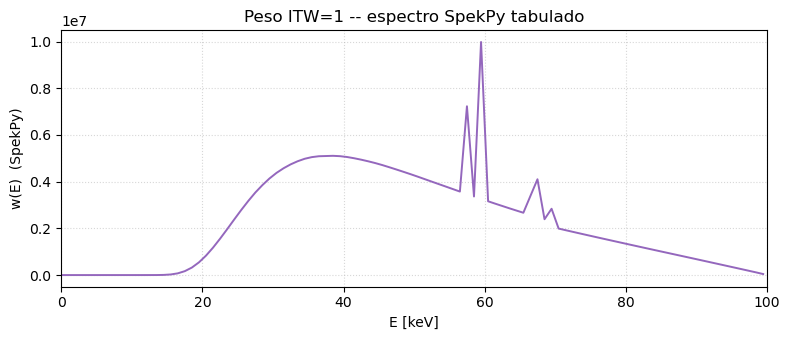

In [8]:
# Configuracion de rutas ITW=1
WEIGHT_SPEKPY_PATH = Path('/home/rober/njoy_work/tapes/spekpy_weight_iwt1_96.txt')
TAPE_HO_ITW1       = Path('/home/rober/njoy_work/tapes/gendf_HO_0_100_10keV_lord3_iwt1')
TAPE_N_ITW1        = Path('/home/rober/njoy_work/tapes/gendf_N_0_100_10keV_lord3_iwt1')

# Cargar peso SpekPy tabulado
if WEIGHT_SPEKPY_PATH.exists():
    weight_itw1 = make_weight_tabulated(WEIGHT_SPEKPY_PATH)
    print(f'OK  Peso ITW=1 cargado: {WEIGHT_SPEKPY_PATH.name}')
    print(f'    Puntos       : {len(weight_itw1.E_keV)}')
    print(f'    Unidad orig. : {weight_itw1.unit_src}')
    print(f'    Rango        : [{weight_itw1.range[0]:.4g}, {weight_itw1.range[1]:.4g}] keV')

    # Grafica del espectro
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.plot(weight_itw1.E_keV, weight_itw1.W, lw=1.4, color='tab:purple')
    ax.set_xlabel('E [keV]'); ax.set_ylabel('w(E)  (SpekPy)')
    ax.set_title('Peso ITW=1 -- espectro SpekPy tabulado')
    ax.grid(True, ls=':', alpha=0.5); ax.set_xlim(0, 100)
    plt.tight_layout(); plt.show()
else:
    print(f'WARNING  No se encuentra el archivo de peso ITW=1:')
    print(f'         {WEIGHT_SPEKPY_PATH}')
    print(f'         Se omite el Bloque 8.')
    weight_itw1 = None


  7.A  sigma_g [cm^-1]  codigo vs XrayDB colapsado  (peso: ITW=1 (tabulado, spekpy_weight_iwt1_96.txt))
  H2O:
Grupo   PE_ref  PE_cod   err_PE  C_ref  C_cod     err_C  T_ref  T_cod     err_T
20-30   0.2432  0.2429  -0.1288 0.1815 0.1815 0.0004711 0.4247 0.4244  -0.07358
30-40   0.0911 0.09111 0.006366 0.1831 0.1831 -0.009024 0.2742 0.2742 -0.003911
40-50   0.0401 0.04016   0.1569 0.1817 0.1817  -0.01614 0.2218 0.2218   0.01515
50-60  0.01957 0.01959   0.1155 0.1785 0.1785  -0.02001 0.1981 0.1981 -0.006613
60-70  0.01162 0.01162 -0.02079 0.1752 0.1752  -0.02272 0.1869 0.1868   -0.0226
70-80 0.007323 0.00731  -0.1697 0.1717 0.1717  -0.01825  0.179  0.179  -0.02445
  |err|max:  PE=0.17%  C=0.02%  T=0.07%

  Aire:
Grupo    PE_ref    PE_cod   err_PE     C_ref     C_cod     err_C     T_ref     T_cod      err_T
20-30 0.0002307 0.0002304   -0.136 0.0001934 0.0001934  0.006294 0.0004241 0.0004238   -0.07113
30-40 8.595e-05 8.596e-05 0.004711 0.0001963 0.0001963 -0.003398 0.0002822 0.0002822 -0.

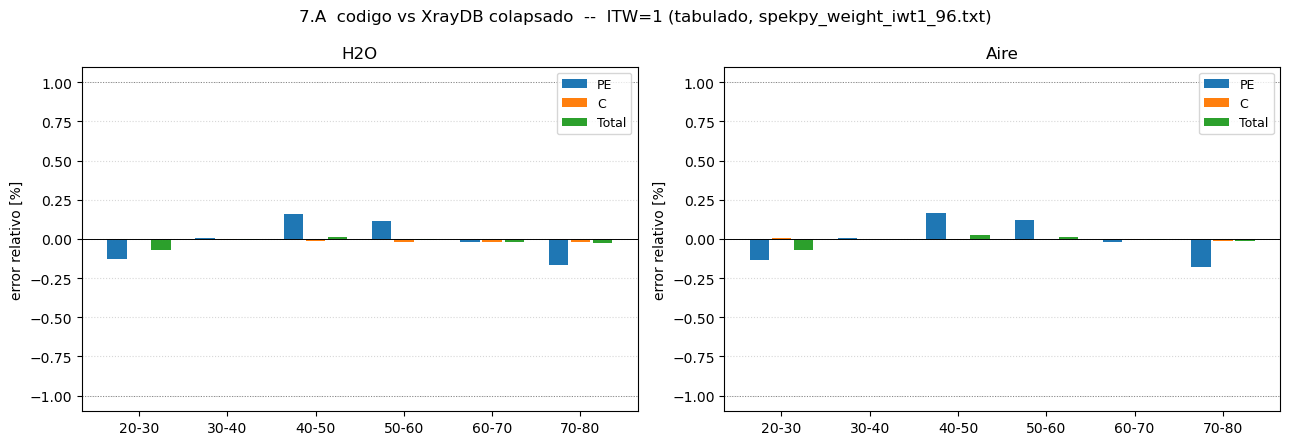

In [9]:
# 7.A ITW=1: codigo vs XrayDB colapsado (mismo peso SpekPy)
if weight_itw1 is not None:
    df8a_itw1 = verify_vs_xraydb(weight_itw1, weight_itw1.label)
else:
    df8a_itw1 = None


  7.B  multigrupo codigo vs NJOY/GAMINR  (ITW=1 (tabulado, spekpy_weight_iwt1_96.txt))
  Tapes leidos: ['H', 'O', 'N']  (11 grupos)
  Bordes [keV]: [0.e+00 1.e+01 2.e+01 3.e+01 4.e+01 5.e+01 6.e+01 7.e+01 8.e+01 9.e+01
 1.e+02 1.e+09]

  7.B.1  sigma_g [barns/atomo]  codigo vs NJOY
  ------------------------------------------------------------------------
  -- H  (Z=1, A=1.0079 g/mol) --
Grupo  C_NJOY  C_cod  errC_%   PE_NJOY    PE_cod  errPE_%  T_NJOY  T_cod  errT_%
20-30  0.5976 0.5982  0.1032 0.0001781 0.0001781 -0.03814  0.5978 0.5984  0.1031
30-40  0.5834 0.5839 0.09132 6.301e-05 6.298e-05 -0.05504  0.5835  0.584 0.09131
40-50  0.5674 0.5679 0.09918 2.661e-05 2.661e-05  0.01311  0.5674  0.568 0.09918
50-60  0.5504 0.5509 0.08714 1.261e-05 1.257e-05  -0.3602  0.5505 0.5509 0.08713
60-70  0.5368 0.5371 0.05465 7.362e-06 7.291e-06  -0.9657  0.5368 0.5371 0.05464
70-80  0.5231 0.5236  0.1006 4.525e-06 4.504e-06  -0.4499  0.5231 0.5236  0.1006
  |err|max:  C=0.10%  PE=0.97%  T=0.10%

 

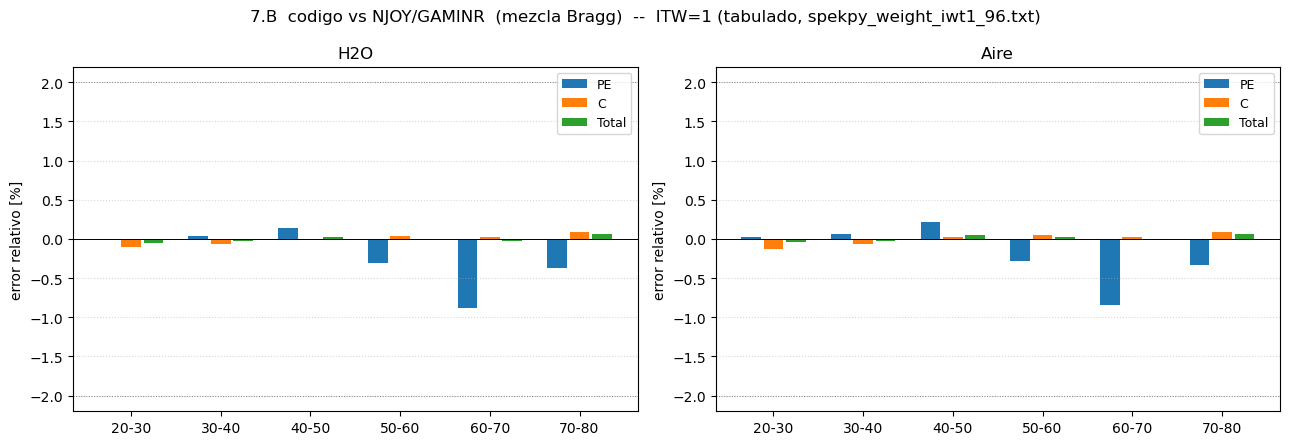

In [10]:
# 7.B ITW=1: codigo vs tapes GENDF NJOY/GAMINR
if weight_itw1 is not None:
    df_elem_itw1, df_mix_itw1 = verify_vs_njoy(weight_itw1, weight_itw1.label,
                                                TAPE_HO_ITW1, TAPE_N_ITW1)
else:
    df_elem_itw1 = df_mix_itw1 = None


## 9. Colapso multigrupo frente a NJOY/GAMINR con `ITW=2`

Caso `ITW=2`: peso constante ($w(E)=1$). Sirve como referencia de control,
ya que elimina la dependencia espectral. Permite comprobar el promedio
energetico de forma directa.


In [11]:
# Configuracion de rutas ITW=2
TAPE_HO_ITW2 = Path('/home/rober/njoy_work/tapes/gendf_HO_0_100_10keV_lord3_iwt2')
TAPE_N_ITW2  = Path('/home/rober/njoy_work/tapes/gendf_N_0_100_10keV_lord3_iwt2')

weight_itw2 = make_weight_flat()
print(f'OK  Peso ITW=2: {weight_itw2.label}')


OK  Peso ITW=2: ITW=2 (plano, w=1)


  7.A  sigma_g [cm^-1]  codigo vs XrayDB colapsado  (peso: ITW=2 (plano, w=1))
  H2O:
Grupo   PE_ref   PE_cod   err_PE  C_ref  C_cod      err_C  T_ref  T_cod     err_T
20-30   0.2895   0.2892  -0.1022 0.1808 0.1808 -0.0009859 0.4704 0.4701  -0.06328
30-40   0.0923   0.0923 0.002765 0.1831 0.1831  -0.008826 0.2754 0.2754 -0.004941
40-50  0.03968  0.03975   0.1573 0.1816 0.1816   -0.01613 0.2213 0.2214   0.01495
50-60  0.02029  0.02031   0.1218 0.1787 0.1787   -0.01952  0.199  0.199 -0.005112
60-70  0.01162  0.01162 -0.02086 0.1752 0.1752   -0.02273 0.1869 0.1868  -0.02261
70-80 0.007216 0.007204   -0.173 0.1716 0.1715   -0.01808 0.1788 0.1787  -0.02433
  |err|max:  PE=0.17%  C=0.02%  T=0.06%

  Aire:
Grupo    PE_ref    PE_cod   err_PE     C_ref     C_cod     err_C     T_ref     T_cod     err_T
20-30 0.0002749 0.0002746  -0.1057 0.0001924 0.0001924  0.004328 0.0004673  0.000467  -0.06038
30-40 8.709e-05 8.709e-05 0.000733 0.0001962 0.0001962 -0.003218 0.0002833 0.0002833 -0.002004
40-50 

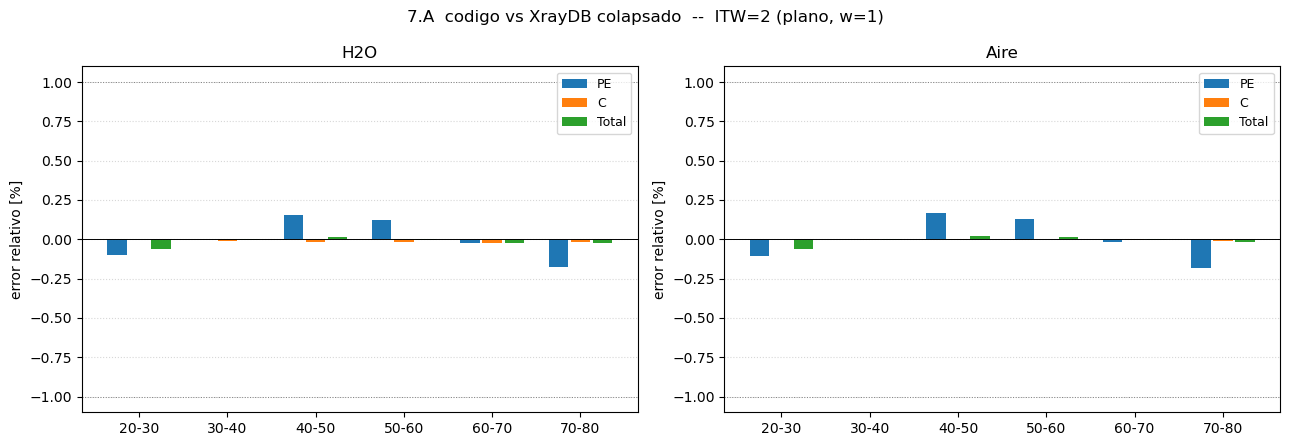

In [12]:
# 7.A ITW=2: codigo vs XrayDB colapsado (mismo peso plano)
df8a_itw2 = verify_vs_xraydb(weight_itw2, weight_itw2.label)


  7.B  multigrupo codigo vs NJOY/GAMINR  (ITW=2 (plano, w=1))
  Tapes leidos: ['H', 'O', 'N']  (11 grupos)
  Bordes [keV]: [0.e+00 1.e+01 2.e+01 3.e+01 4.e+01 5.e+01 6.e+01 7.e+01 8.e+01 9.e+01
 1.e+02 1.e+09]

  7.B.1  sigma_g [barns/atomo]  codigo vs NJOY
  ------------------------------------------------------------------------
  -- H  (Z=1, A=1.0079 g/mol) --
Grupo  C_NJOY  C_cod  errC_%   PE_NJOY    PE_cod  errPE_%  T_NJOY  T_cod  errT_%
20-30  0.5994    0.6 0.09976 0.0002149 0.0002145  -0.1806  0.5997 0.6002 0.09966
30-40  0.5836 0.5842 0.09004 6.391e-05 6.385e-05 -0.09498  0.5837 0.5842 0.09002
40-50  0.5671 0.5677  0.0997 2.632e-05 2.633e-05  0.03335  0.5672 0.5677 0.09969
50-60  0.5513 0.5519  0.1092 1.303e-05 1.305e-05  0.09406  0.5513 0.5519  0.1092
60-70  0.5366 0.5371 0.09625 7.294e-06 7.289e-06 -0.07038  0.5366 0.5371 0.09625
70-80  0.5226 0.5232   0.106 4.449e-06 4.436e-06  -0.2891  0.5226 0.5232   0.106
  |err|max:  C=0.11%  PE=0.29%  T=0.11%

  -- N  (Z=7, A=14.007 g/m

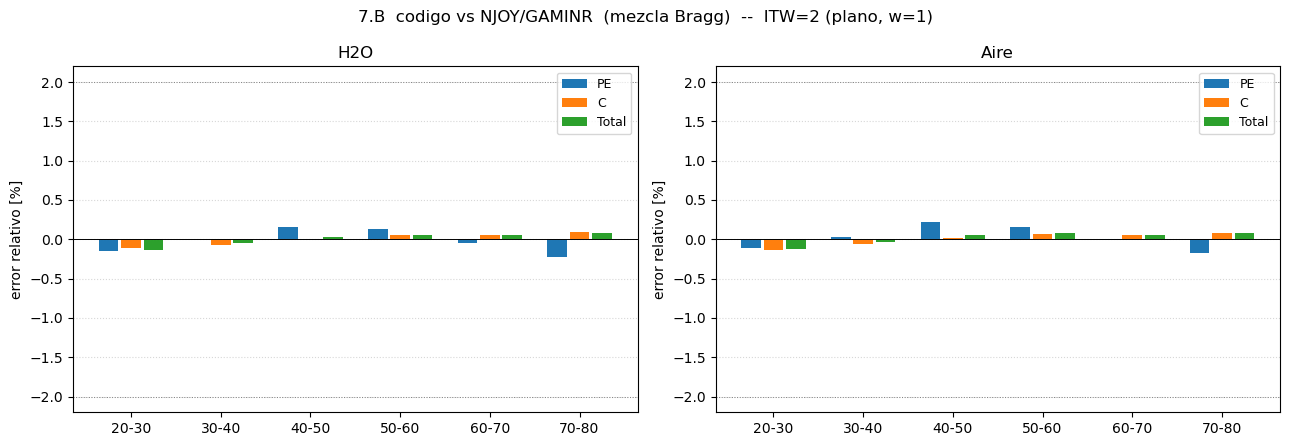

In [13]:
# 7.B ITW=2: codigo vs tapes GENDF NJOY/GAMINR
df_elem_itw2, df_mix_itw2 = verify_vs_njoy(weight_itw2, weight_itw2.label,
                                            TAPE_HO_ITW2, TAPE_N_ITW2)


## 10. Colapso multigrupo frente a NJOY/GAMINR con `ITW=3`

Caso `ITW=3`: peso $1/E$ con suavizados en los extremos (peso clasico en
procesamiento multigrupo). Permite evaluar la sensibilidad del codigo a
funciones de peso con fuerte variacion energetica.

> **Nota.** En los tapes de la version actual del flujo de trabajo se ha
> observado que el flux almacenado en MF=23 sigue $\mathrm{flux}_g\propto
> \int E^2\,dE$, es decir, el peso *efectivo* del tape es $w(E)=E^2$. Si
> sus tapes lo confirman, use `weight_itw3 = make_weight_E_squared()`; si
> el procesamiento usa el peso $1/E$ canonico, use
> `make_weight_one_over_E()`. Aqui se prueban ambos para diagnostico.


OK  Peso ITW=3 (EFFECTIVE): ITW=3 efectivo (E^2)


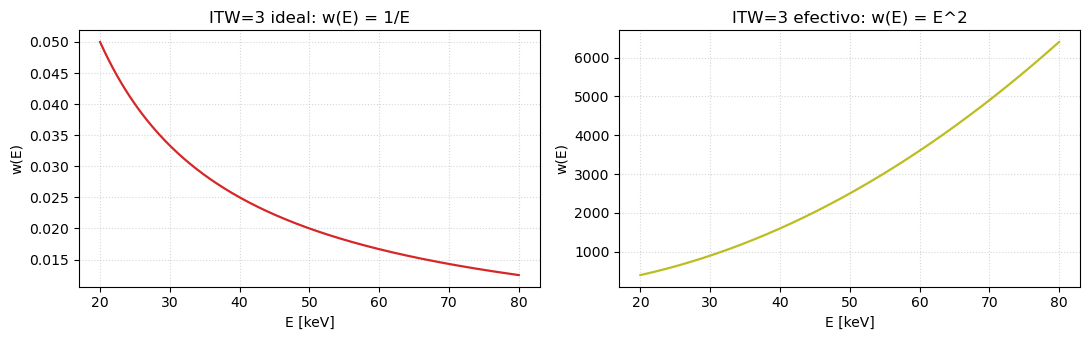

In [14]:
# Configuracion de rutas ITW=3
TAPE_HO_ITW3 = Path('/home/rober/njoy_work/tapes/gendf_HO_0_100_10keV_lord3_iwt3')
TAPE_N_ITW3  = Path('/home/rober/njoy_work/tapes/gendf_N_0_100_10keV_lord3_iwt3')

# Eleccion del peso para el caso ITW=3 ---------------------------------------
# Cambiar a 'IDEAL' si los tapes utilizan el peso 1/E canonico
ITW3_MODE = 'EFFECTIVE'   # 'IDEAL' (1/E)  o  'EFFECTIVE' (E^2)

if ITW3_MODE == 'IDEAL':
    weight_itw3 = make_weight_one_over_E()
elif ITW3_MODE == 'EFFECTIVE':
    weight_itw3 = make_weight_E_squared()
else:
    raise ValueError(f'ITW3_MODE no reconocido: {ITW3_MODE}')

print(f'OK  Peso ITW=3 ({ITW3_MODE}): {weight_itw3.label}')

# Comparacion grafica de ambos pesos para contexto
E_grid = np.linspace(20, 80, 200)
w_ideal     = np.array([make_weight_one_over_E()(E) for E in E_grid])
w_effective = np.array([make_weight_E_squared()(E)  for E in E_grid])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(E_grid, w_ideal, lw=1.6, color='tab:red')
axes[0].set_title('ITW=3 ideal: w(E) = 1/E')
axes[1].plot(E_grid, w_effective, lw=1.6, color='tab:olive')
axes[1].set_title('ITW=3 efectivo: w(E) = E^2')
for ax in axes:
    ax.set_xlabel('E [keV]'); ax.set_ylabel('w(E)')
    ax.grid(True, ls=':', alpha=0.5)
plt.tight_layout(); plt.show()


  7.A  sigma_g [cm^-1]  codigo vs XrayDB colapsado  (peso: ITW=3 efectivo (E^2))
  H2O:
Grupo   PE_ref   PE_cod   err_PE  C_ref  C_cod      err_C  T_ref  T_cod     err_T
20-30   0.2654   0.2651  -0.1141 0.1812 0.1812 -0.0002764 0.4466 0.4463   -0.0679
30-40  0.08828   0.0883  0.01445 0.1831 0.1831  -0.009556 0.2714 0.2714 -0.001745
40-50  0.03863  0.03869   0.1582 0.1816 0.1815   -0.01613 0.2202 0.2202   0.01445
50-60  0.01992  0.01995    0.119 0.1786 0.1786   -0.01974 0.1985 0.1985 -0.005823
60-70  0.01147  0.01147 -0.02534 0.1751 0.1751   -0.02267 0.1866 0.1866  -0.02283
70-80 0.007147 0.007134  -0.1752 0.1715 0.1715   -0.01796 0.1786 0.1786  -0.02425
  |err|max:  PE=0.18%  C=0.02%  T=0.07%

  Aire:
Grupo    PE_ref    PE_cod   err_PE     C_ref     C_cod     err_C     T_ref     T_cod     err_T
20-30 0.0002519 0.0002516  -0.1193 0.0001929 0.0001929  0.005289 0.0004447 0.0004445  -0.06524
30-40 8.328e-05 8.329e-05  0.01364 0.0001963 0.0001963 -0.003835 0.0002796 0.0002796  0.001371
40-5

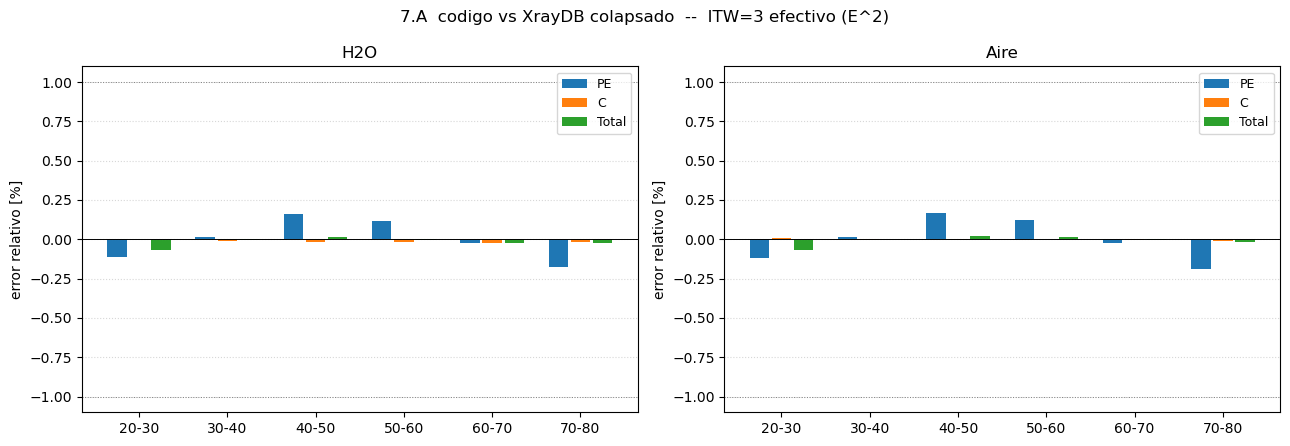

In [15]:
# 7.A ITW=3: codigo vs XrayDB colapsado (mismo peso seleccionado)
df8a_itw3 = verify_vs_xraydb(weight_itw3, weight_itw3.label)


  7.B  multigrupo codigo vs NJOY/GAMINR  (ITW=3 efectivo (E^2))
  Tapes leidos: ['H', 'O', 'N']  (11 grupos)
  Bordes [keV]: [0.e+00 1.e+01 2.e+01 3.e+01 4.e+01 5.e+01 6.e+01 7.e+01 8.e+01 9.e+01
 1.e+02 1.e+09]

  7.B.1  sigma_g [barns/atomo]  codigo vs NJOY
  ------------------------------------------------------------------------
  -- H  (Z=1, A=1.0079 g/mol) --
Grupo  C_NJOY  C_cod  errC_%   PE_NJOY    PE_cod   errPE_%  T_NJOY  T_cod  errT_%
20-30  0.5985 0.5991  0.1025 0.0001957 0.0001955  -0.07387  0.5987 0.5993  0.1024
30-40  0.5828 0.5834 0.09248 6.094e-05 6.093e-05 -0.006666  0.5829 0.5834 0.09247
40-50  0.5665 0.5671  0.1022 2.557e-05 2.559e-05    0.1141  0.5665 0.5671  0.1022
50-60  0.5508 0.5514  0.1125 1.279e-05  1.28e-05    0.1293  0.5508 0.5515  0.1125
60-70  0.5362 0.5367  0.1004 7.193e-06 7.191e-06  -0.02953  0.5362 0.5367  0.1004
70-80  0.5223 0.5229  0.1061 4.403e-06 4.392e-06   -0.2526  0.5223 0.5229  0.1061
  |err|max:  C=0.11%  PE=0.25%  T=0.11%

  -- N  (Z=7, A=1

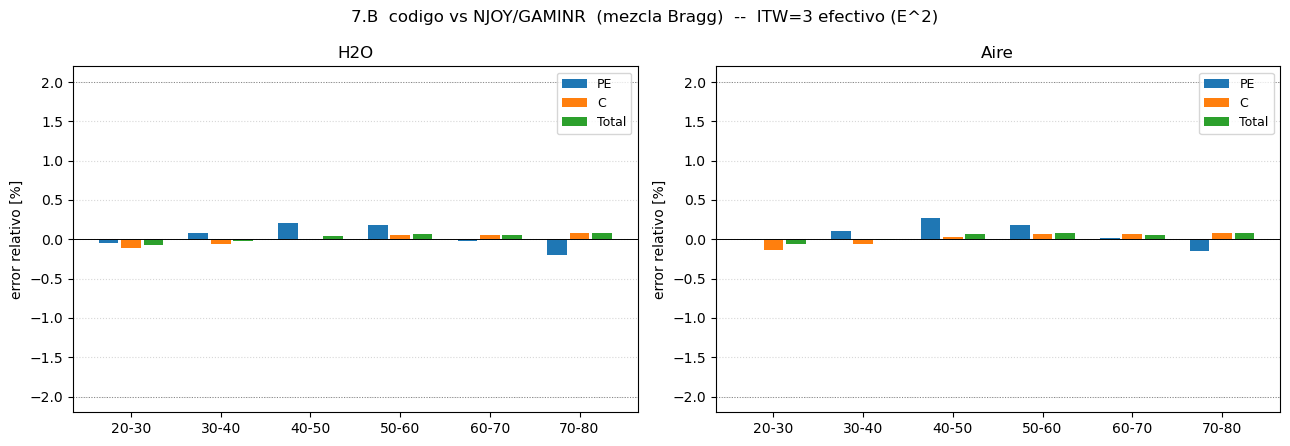

In [16]:
# 7.B ITW=3: codigo vs tapes GENDF NJOY/GAMINR
df_elem_itw3, df_mix_itw3 = verify_vs_njoy(weight_itw3, weight_itw3.label,
                                            TAPE_HO_ITW3, TAPE_N_ITW3)


## 11. Resumen tecnico final

Tabla compacta con los errores maximos por bloque para los tres casos
`ITW=1`, `ITW=2`, `ITW=3`.

**Criterios de aceptacion sugeridos:**
* XS puntuales (Bloque 6) -- $|\text{err}|<2\%$ vs XrayDB.
* MG vs XrayDB colapsado (7.A) -- $|\text{err}|<1\%$ (determinista, mismo peso).
* MG vs NJOY/GAMINR (7.B) -- $|\text{err}|<2\%$ (admite diferencias de
  malla de integracion).


In [17]:
# Resumen final
rows = []


def _add_row(bloque, magnitud, material, ref, valor):
    rows.append({'Bloque':bloque, 'Magnitud':magnitud,
                 'Material':material, 'Ref':ref, 'Estado':valor})


# Bloque 6 (XS puntuales)
if res_punt is not None:
    for name, df in res_punt.items():
        _add_row('Bloque 6 (puntual)',
                 'mu_PE/rho [cm2/g]', name, 'XrayDB/NIST',
                 f'max={df.err_PE.abs().max():.2f}%')
        _add_row('Bloque 6 (puntual)',
                 'mu_C/rho [cm2/g]', name, 'XrayDB/NIST',
                 f'max={df.err_C.abs().max():.2f}%')


# Bloques 8/9/10 (multigrupo)
def _add_xrdb(df, itw_label):
    if df is None:
        _add_row(f'7.A {itw_label}', 'sigma_g total [cm^-1]', '---',
                 f'XrayDB colapsado {itw_label}', 'XrayDB no disponible')
        return
    for name in ('H2O', 'Aire'):
        s = df[df.Mat == name]
        _add_row(f'7.A {itw_label}', 'sigma_g total [cm^-1]', name,
                 f'XrayDB colapsado {itw_label}',
                 f'max={s.err_T.abs().max():.2f}%')


def _add_njoy(df_elem, df_mix, itw_label):
    if df_elem is not None:
        for elem in ('H', 'N', 'O'):
            s = df_elem[df_elem.Elem == elem]
            if s.empty:
                continue
            _add_row(f'7.B {itw_label}', 'sigma_g total [barns/atomo]', elem,
                     f'NJOY/GAMINR MF=23 {itw_label}',
                     f'max_C={s["errC_%"].abs().max():.2f}%  '
                     f'max_PE={s["errPE_%"].abs().max():.2f}%  '
                     f'max_T={s["errT_%"].abs().max():.2f}%')
    else:
        _add_row(f'7.B {itw_label}', 'sigma_g (barns/atomo)', '---',
                 f'NJOY MF=23 {itw_label}', 'Tapes no encontrados')

    if df_mix is not None:
        for name in ('H2O', 'Aire'):
            s = df_mix[df_mix.Mat == name]
            _add_row(f'7.B {itw_label}', 'sigma_g total [cm^-1]', name,
                     f'NJOY/GAMINR MF=23 {itw_label}',
                     f'max_C={s["errC_%"].abs().max():.2f}%  '
                     f'max_PE={s["errPE_%"].abs().max():.2f}%  '
                     f'max_T={s["errT_%"].abs().max():.2f}%')


_add_xrdb(df8a_itw1, 'ITW=1')
_add_njoy(df_elem_itw1, df_mix_itw1, 'ITW=1')

_add_xrdb(df8a_itw2, 'ITW=2')
_add_njoy(df_elem_itw2, df_mix_itw2, 'ITW=2')

_add_xrdb(df8a_itw3, 'ITW=3')
_add_njoy(df_elem_itw3, df_mix_itw3, 'ITW=3')

df_resumen = pd.DataFrame(rows)
pd.set_option('display.width', 180)
pd.set_option('display.max_colwidth', 48)

SEP = '=' * 88
print(SEP)
print('  RESUMEN FINAL  --  Verificacion de secciones eficaces multigrupo')
print(SEP)
print(df_resumen.to_string(index=False))
print(SEP)
print('  Criterios:')
print('    Bloque 6   (XS puntuales)            |err| < 2%   vs XrayDB/NIST')
print('    Bloque 7.A (MG vs XrayDB colapsado)  |err| < 1%   (determinista)')
print('    Bloque 7.B (MG vs NJOY/GAMINR)       |err| < 2%   (malla NJOY)')
print(SEP)


  RESUMEN FINAL  --  Verificacion de secciones eficaces multigrupo
            Bloque                    Magnitud Material                     Ref                                 Estado
Bloque 6 (puntual)           mu_PE/rho [cm2/g]      H2O             XrayDB/NIST                              max=0.21%
Bloque 6 (puntual)            mu_C/rho [cm2/g]      H2O             XrayDB/NIST                              max=0.02%
Bloque 6 (puntual)           mu_PE/rho [cm2/g]     Aire             XrayDB/NIST                              max=0.23%
Bloque 6 (puntual)            mu_C/rho [cm2/g]     Aire             XrayDB/NIST                              max=0.01%
         7.A ITW=1       sigma_g total [cm^-1]      H2O  XrayDB colapsado ITW=1                              max=0.07%
         7.A ITW=1       sigma_g total [cm^-1]     Aire  XrayDB colapsado ITW=1                              max=0.07%
         7.B ITW=1 sigma_g total [barns/atomo]        H NJOY/GAMINR MF=23 ITW=1 max_C=0.10%  max_PE=

## 12. Comparativa visual de los tres pesos

Grafico de barras agrupado con el error maximo de $\sigma_T^g$ (mezcla H2O
y aire) en los tres casos `ITW=1`, `ITW=2`, `ITW=3`, para apreciar de un
vistazo la sensibilidad del codigo a la funcion de ponderacion.


Error maximo |err_T| [%] (mezcla Bragg vs NJOY)
          H2O    Aire
ITW                  
ITW=1  0.0653 0.06726
ITW=2  0.1371  0.1236
ITW=3 0.07494 0.08184


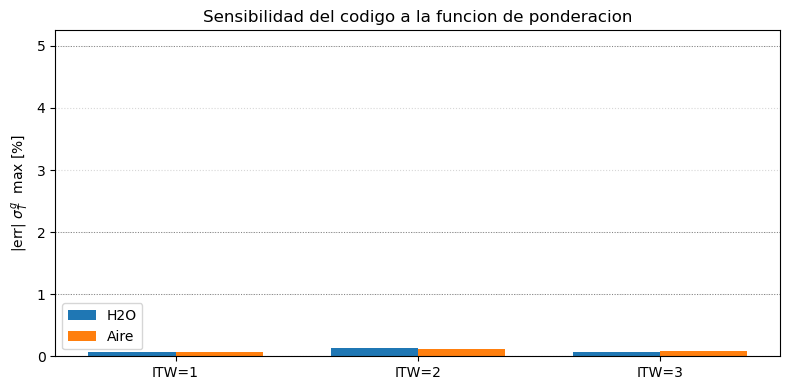

In [18]:
def _max_err_T(df_mix, mat):
    if df_mix is None:
        return float('nan')
    s = df_mix[df_mix.Mat == mat]
    return s['errT_%'].abs().max() if not s.empty else float('nan')


bars_data = []
for itw_lbl, df_mix in [('ITW=1', df_mix_itw1),
                         ('ITW=2', df_mix_itw2),
                         ('ITW=3', df_mix_itw3)]:
    bars_data.append({'ITW': itw_lbl,
                      'H2O':  _max_err_T(df_mix, 'H2O'),
                      'Aire': _max_err_T(df_mix, 'Aire')})

df_bars = pd.DataFrame(bars_data).set_index('ITW')
print('Error maximo |err_T| [%] (mezcla Bragg vs NJOY)')
print(df_bars.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(df_bars))
ax.bar(x - 0.18, df_bars['H2O'],  0.36, label='H2O',  color='tab:blue')
ax.bar(x + 0.18, df_bars['Aire'], 0.36, label='Aire', color='tab:orange')
for yv in [1, 2, 5]:
    ax.axhline(yv, color='grey', ls=':', lw=0.7)
ax.set_xticks(x); ax.set_xticklabels(df_bars.index)
ax.set_ylabel(r'|err| $\sigma_T^g$  max [%]')
ax.set_title('Sensibilidad del codigo a la funcion de ponderacion')
ax.legend(); ax.grid(True, axis='y', ls=':', alpha=0.5)
plt.tight_layout(); plt.show()


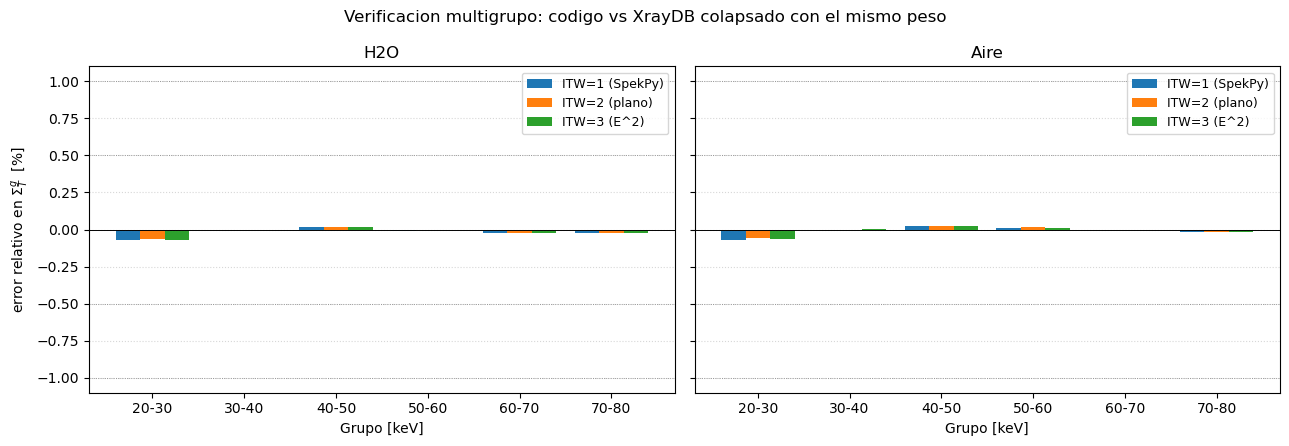

|err|_max [%]  --  codigo vs XrayDB colapsado
--------------------------------------------------------
                    ITW=1 (SpekPy)     ITW=2 (plano)       ITW=3 (E^2)
H2O                          0.074             0.063             0.068
Aire                         0.071             0.060             0.065


In [19]:
# =============================================================================
# Verificacion XS multigrupo: codigo vs XrayDB colapsado con el mismo peso.
# Una unica grafica con los 3 casos (ITW=1, ITW=2, ITW=3) x 2 materiales.
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt

# --- pesos a comparar ----------------------------------------------------
# weight_itw1 puede ser None si no se pudo cargar el archivo SpekPy
weights = []
if weight_itw1 is not None:
    weights.append(('ITW=1 (SpekPy)', weight_itw1))
weights.append(('ITW=2 (plano)',  make_weight_flat()))
weights.append(('ITW=3 (E^2)',    make_weight_E_squared()))

MATS = [('H2O',  COMP_H2O, RHO_H2O, H2O_WFRAC),
        ('Aire', COMP_AIR, RHO_AIR, AIRE_WFRAC)]

# --- calculo: error relativo (%) por grupo, mezcla, peso -----------------
errors = {}   # errors[(mat, lbl)] = array (N_G,)
for name, comp, rho, wfrac in MATS:
    for lbl, wfn in weights:
        mg_xs = MultiGroupCrossSections(xs, wfn)
        e = []
        for gb in GROUP_BTE_IDX:
            pe_r = xrdb_avg_g(gb, 'photo', wfrac, wfn) * rho
            co_r = xrdb_avg_g(gb, 'incoh', wfrac, wfn) * rho
            tt_r = pe_r + co_r
            tt_c = mg_xs.sigma_pe_g(gb, rho, comp) + mg_xs.sigma_compton_g(gb, rho, comp)
            e.append(100*(tt_c - tt_r)/tt_r if tt_r > 0 else np.nan)
        errors[(name, lbl)] = np.array(e)

# --- grafica -------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
x = np.arange(len(GROUP_LABELS))
w = 0.8 / len(weights)
colors = ['tab:blue', 'tab:orange', 'tab:green']

for i, (name, *_ ) in enumerate(MATS):
    ax = axes[i]
    for k, (lbl, _) in enumerate(weights):
        offset = (k - (len(weights)-1)/2) * w
        ax.bar(x + offset, errors[(name, lbl)], w, label=lbl, color=colors[k])
    ax.axhline(0, color='k', lw=0.7)
    for yv in [0.5, -0.5, 1.0, -1.0]:
        ax.axhline(yv, color='grey', ls=':', lw=0.6)
    ax.set_xticks(x); ax.set_xticklabels(GROUP_LABELS)
    ax.set_xlabel('Grupo [keV]')
    ax.set_title(name)
    ax.grid(True, axis='y', ls=':', alpha=0.5)
    ax.legend(fontsize=9, loc='best')
axes[0].set_ylabel(r'error relativo en $\Sigma_T^g$  [%]')
fig.suptitle('Verificacion multigrupo: codigo vs XrayDB colapsado con el mismo peso',
             fontsize=12)
plt.tight_layout(); plt.show()

# --- error maximo por caso ----------------------------------------------
print('|err|_max [%]  --  codigo vs XrayDB colapsado')
print('-' * 56)
print(f'{"":<18}' + '  '.join(f'{lbl:>16}' for lbl, _ in weights))
for name, *_ in MATS:
    row = [f'{np.nanmax(np.abs(errors[(name, lbl)])):>16.3f}' for lbl, _ in weights]
    print(f'{name:<18}' + '  '.join(row))